# Lab Day 1 — Notebook

> **Quy trình làm bài**
> 1. Viết các module trực tiếp trong `code/` bằng VS Code.
> 2. Đồng bộ lên GitHub bằng commit/push; trên Colab cập nhật repo bằng git pull trước khi chạy.
> 3. Ô thiết lập bên dưới dùng `REPO/code/` để chạy, lưu ảnh/kết quả vào `submission_<MSSV>/`.
> 4. Cuối bài, copy code hoàn thiện vào `submission_<MSSV>/code/`, lưu notebook có output vào đó.
> 5. Sau khi hoàn thiện các TODO: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [2]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
from pathlib import Path

MSSV = "2A202602457"
REPO_URL = "https://github.com/sown101/K4-Track4-Day1-Neuralnetwork.git"

try:
    from google.colab import drive
except ImportError:
    IN_COLAB = False
    candidates = [Path.cwd(), *Path.cwd().parents]
    REPO = next((p for p in candidates if (p / "data").is_dir() and (p / "scripts").is_dir() and ((p / "code/lab.ipynb").is_file() or (p / f"submission_{MSSV}/code/lab.ipynb").is_file())), None)
    if REPO is None:
        raise FileNotFoundError("Hãy mở notebook từ thư mục dự án.")
else:
    IN_COLAB = True
    drive.mount("/content/drive")
    REPO = Path("/content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork")
    if not REPO.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO)], check=True)
    # Cập nhật code mới nhất đã push từ máy cá nhân.
    subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only"], check=True)

REPO = REPO.resolve()
SUBMISSION = REPO / f"submission_{MSSV}"
# Chạy từ submission_<MSSV>/code/ (bản nộp) thì dùng code cạnh notebook; trên Colab dùng REPO/code.
CODE_DIR = Path.cwd() if (Path.cwd() / "train.py").is_file() and (Path.cwd() / "runner.py").is_file() else REPO / "code"
for name in ("figures", "results"):
    (SUBMISSION / name).mkdir(parents=True, exist_ok=True)
os.chdir(CODE_DIR)
sys.path.insert(0, str(CODE_DIR))
REPO_ROOT = str(REPO)
OUT_DIR = str(SUBMISSION)

import numpy as np, torch
device = "cuda" if torch.cuda.is_available() else "cpu"
if IN_COLAB and device != "cuda":
    raise RuntimeError("Hãy bật GPU trong Runtime trước khi tiếp tục.")
print("PyTorch:", torch.__version__)
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Thư mục code:", CODE_DIR)
print("Thư mục kết quả:", OUT_DIR)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx
from runner import run_or_load

# LAB_SMOKE=1: chạy thử nhanh pipeline (ít dữ liệu, ít epoch) — KHÔNG dùng cho kết quả nộp
SMOKE = os.environ.get("LAB_SMOKE") == "1"
FORCE_RERUN = False      # True: bỏ qua kết quả JSON đã lưu và huấn luyện lại tất cả
CKPT_DIR = str(REPO / "checkpoints")   # trọng số baseline/final để dự đoán eval; không nộp
%matplotlib inline

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.11.0+cu130
Device: cuda
GPU: Tesla T4
Thư mục code: /content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/code
Thư mục kết quả: /content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602457


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation (20% của train, phân tầng, seed 42), chuẩn hoá 10 cột số bằng thống kê **chỉ của phần train còn lại**, đưa toàn bộ lên device một lần.

In [3]:
processed_dir = REPO / "data" / "processed"
if not all((processed_dir / f"{name}.npz").is_file() for name in ("train", "eval")):
    completed = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True, capture_output=True, text=True)
    print(completed.stdout)
for name in ("train", "eval"):
    with np.load(processed_dir / f"{name}.npz") as dataset:
        print(name, "X:", dataset["X"].shape, dataset["X"].dtype, "y:", dataset["y"].shape, dataset["y"].dtype, "nhãn:", dataset["y"].min(), "..", dataset["y"].max())

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
assert len(data["X_tr"]) == 371_847 and len(data["X_val"]) == 92_962 and len(data["X_eval"]) == 116_203
num = data["X_tr"][:, :10]
print("mean 10 cột số (X_tr):", num.mean(0).cpu().numpy().round(4))
print("std  10 cột số (X_tr):", num.std(0).cpu().numpy().round(4))

if SMOKE:  # chỉ để kiểm tra code chạy được trên CPU
    g = torch.Generator().manual_seed(0)
    for k, n in (("tr", 20_000), ("val", 5_000)):
        idx = torch.randperm(len(data[f"X_{k}"]), generator=g)[:n].to(device)
        data[f"X_{k}"], data[f"y_{k}"] = data[f"X_{k}"][idx], data[f"y_{k}"][idx]
    print("SMOKE: dùng tập con", len(data["X_tr"]), len(data["X_val"]))

train X: (464809, 54) float32 y: (464809,) int64 nhãn: 0 .. 6
eval X: (116203, 54) float32 y: (116203,) int64 nhãn: 0 .. 6
train (sau tách val): 371,847   val: 92,962   eval: 116,203
lớp đa số trên train = 1; accuracy 'luôn đoán lớp đa số' trên val = 0.4876
tỉ lệ lớp (%)  train / val / eval:
  train [36.46 48.76  6.15  0.47  1.63  2.99  3.53]
  val   [36.46 48.76  6.15  0.47  1.63  2.99  3.53]
  eval  [36.46 48.76  6.15  0.47  1.63  2.99  3.53]
X_tr 10 cột số: mean ∈ [-3.52e-07, 1.69e-07], std ∈ [0.9998, 1.0008]
mean 10 cột số (X_tr): [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
std  10 cột số (X_tr): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Nhận xét Part 0:** kích thước đúng quy định (371 847 / 92 962 / 116 203); tỉ lệ lớp ở train, val, eval gần như trùng nhau nhờ phân tầng;
10 cột số sau chuẩn hoá có mean ≈ 0, std ≈ 1 trên X_tr. Mốc thấp nhất "luôn đoán lớp 1" trên val ≈ 0,4876.
Mean/std chỉ tính trên phần train còn lại; X_eval chỉ được *áp dụng* phép chuẩn hoá đó, không tham gia tính thống kê, chọn cấu hình hay dừng sớm.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [4]:
import math
import matplotlib.pyplot as plt
import torch.nn.functional as F

set_seed(1)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
assert n_params == EXPECTED_PARAMS[(256, 128)], n_params
print(model)
print("số tham số:", n_params)
for k, (h, n) in enumerate(EXPECTED_PARAMS.items()):
    assert count_params(MLP(hidden=h)) == n
print("M-wide / M-deep:", count_params(MLP(hidden=(512, 256))), "/", count_params(MLP(hidden=(256, 128, 64))))

# 1b. shape qua từng lớp
x = torch.randn(8, 54, device=device)
h = x
for layer in model.net:
    h = layer(h)
    print(f"{layer.__class__.__name__:8s} -> {tuple(h.shape)}")
assert model(x).shape == (8, 7)

# 1c-1. loss bước 0 trên toàn bộ val (eval mode)
step0 = evaluate(model, data["X_val"], data["y_val"])
print(f"\nloss bước 0 trên val = {step0['loss']:.4f}   (ln 7 = {math.log(7):.4f})")
print("độ lệch chuẩn kích hoạt sau mỗi ReLU / logit (He):", [round(s, 3) for s in activation_stats(model, data["X_val"][:4096])])

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47879
M-wide / M-deep: 161287 / 55687
Linear   -> (8, 256)
ReLU     -> (8, 256)
Linear   -> (8, 128)
ReLU     -> (8, 128)
Linear   -> (8, 7)

loss bước 0 trên val = 2.2691   (ln 7 = 1.9459)
độ lệch chuẩn kích hoạt sau mỗi ReLU / logit (He): [0.39, 0.366, 0.577]


loss ban đầu 2.1983 -> sau 500 bước 0.000177;  accuracy trên 20 mẫu = 1.00
các nhãn trong 20 mẫu: [8, 9, 1, 0, 0, 1, 1]


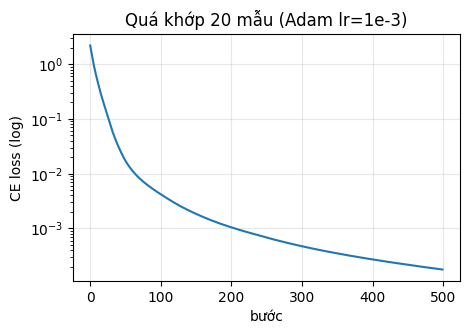

W1 (net.0.weight) shape (256, 54)    ‖grad‖ = 0.50705
b1 (net.0.bias  ) shape (256,)       ‖grad‖ = 0.34224
W2 (net.2.weight) shape (128, 256)   ‖grad‖ = 2.02123
b2 (net.2.bias  ) shape (128,)       ‖grad‖ = 0.44387
W3 (net.4.weight) shape (7, 128)     ‖grad‖ = 1.96046
b3 (net.4.bias  ) shape (7,)         ‖grad‖ = 0.57246


In [5]:
# 1c-2. quá khớp 20 mẫu (dropout tắt): loss phải về gần 0
set_seed(0)
tiny = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
idx = torch.randperm(len(data["X_tr"]), generator=torch.Generator().manual_seed(0))[:20].to(device)
xb, yb = data["X_tr"][idx], data["y_tr"][idx]
opt = build_optimizer("adam", tiny.parameters(), lr=1e-3)
curve = []
for step in range(500):
    tiny.train()
    loss = F.cross_entropy(tiny(xb), yb)
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
    curve.append(loss.item())
acc20 = (predict(tiny, xb) == yb).float().mean().item()
print(f"loss ban đầu {curve[0]:.4f} -> sau 500 bước {curve[-1]:.6f};  accuracy trên 20 mẫu = {acc20:.2f}")
print("các nhãn trong 20 mẫu:", torch.bincount(yb, minlength=7).tolist())
plt.figure(figsize=(5, 3.2))
plt.semilogy(curve); plt.xlabel("bước"); plt.ylabel("CE loss (log)"); plt.title("Quá khớp 20 mẫu (Adam lr=1e-3)"); plt.grid(alpha=.3)
plt.show()
assert curve[-1] < 1e-2 and acc20 == 1.0

# 1d. gradient có chảy tới mọi tham số?
model.train()
loss = F.cross_entropy(model(data["X_tr"][:512]), data["y_tr"][:512])
model.zero_grad(); loss.backward()
names = ["W1", "b1", "W2", "b2", "W3", "b3"]
for nm, (pname, p) in zip(names, model.named_parameters()):
    gn = p.grad.norm().item() if p.grad is not None else None
    print(f"{nm} ({pname:12s}) shape {tuple(p.shape)!s:12s} ‖grad‖ = {gn:.5f}")
    assert p.grad is not None and gn > 0

**Nhận xét Part 1:**
- Số tham số đúng 47 879 (có `assert`; M-wide 161 287, M-deep 55 687 cũng khớp), logits `(B, 7)`; softmax không nằm trong model mà trong `F.cross_entropy`.
- Loss bước 0 đo được = **2,269** với seed 1, cao hơn ln 7 = 1,946 khoảng 0,32. Nguyên nhân: khởi tạo He giữ phương sai kích hoạt qua các lớp ReLU nên logit ở bước 0 có std ≈ 0,58 (xem dòng độ lệch chuẩn kích hoạt), không đủ nhỏ để softmax đều tuyệt đối. Giá trị này dao động theo seed (base-s2: 1,978; base-s3: 1,900; M-wide/M-deep: 1,92/1,91), tức không phải lỗi hệ thống. Với `zeros`/`normal` (logit ≈ 0) loss bước 0 đúng bằng 1,9459–1,9460 (chủ đề 7) — xác nhận đường tính loss đúng.
- Quá khớp 20 mẫu: loss 2,198 → 0,000177 sau 500 bước, accuracy 100% → vòng lặp (nhãn, loss, `zero_grad`, optimizer nhận tham số) không có lỗi cơ bản.
- Cả 6 tham số W1, b1, W2, b2, W3, b3 đều có gradient khác 0 (0,34–2,02) → gradient chảy tới mọi lớp.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` (trong `train.py`) nhận một dict cấu hình và trả về lịch sử + tóm tắt. `run_or_load` (trong `runner.py`) gọi nó,
lưu `results/<exp_id>.json` và ảnh `figures/<exp_id>.png`. Baseline: SGD+momentum 0,9, CE, He, batch 512, 20 epoch, dropout 0, không clip, FP32.

Mỗi epoch ghi: train loss (eval mode, 50 000 mẫu train cố định), val loss/acc/macro-F1, grad_norm trung bình và lớn nhất (trước clip), tỉ lệ bước bị clip,
thời gian epoch; cùng loss bước 0, best epoch theo val loss, bộ nhớ GPU cực đại, cờ diverged.

**Chọn lr cho baseline bằng VAL.** Dự đoán: lr = 0,01 sẽ chậm (20 epoch chưa đủ), lr quá lớn (0,3, tương đương bước hiệu dụng lr/(1−μ) = 3) có thể dao động;
giá trị tốt nhất có lẽ quanh 0,03–0,1. Các lần chạy này cũng là thí nghiệm "độ nhạy lr" của SGD+momentum (nhóm `optimizer`).

[opt-sgdm-lr0.01] ep  1  train 0.5756  val 0.5797  acc 0.7546  F1 0.5135  |g| 0.430  1.3s
[opt-sgdm-lr0.01] ep  2  train 0.5258  val 0.5295  acc 0.7758  F1 0.5968  |g| 0.504  1.5s
[opt-sgdm-lr0.01] ep  3  train 0.4923  val 0.4954  acc 0.7914  F1 0.5987  |g| 0.590  1.4s
[opt-sgdm-lr0.01] ep  4  train 0.4757  val 0.4806  acc 0.7977  F1 0.6321  |g| 0.710  1.3s
[opt-sgdm-lr0.01] ep  5  train 0.4431  val 0.4486  acc 0.8120  F1 0.6271  |g| 0.788  1.2s
[opt-sgdm-lr0.01] ep  6  train 0.4605  val 0.4670  acc 0.8003  F1 0.6464  |g| 0.904  1.2s
[opt-sgdm-lr0.01] ep  7  train 0.4077  val 0.4141  acc 0.8268  F1 0.6758  |g| 0.976  1.2s
[opt-sgdm-lr0.01] ep  8  train 0.4074  val 0.4130  acc 0.8239  F1 0.6891  |g| 1.003  1.3s
[opt-sgdm-lr0.01] ep  9  train 0.3892  val 0.3961  acc 0.8347  F1 0.6812  |g| 1.039  1.2s
[opt-sgdm-lr0.01] ep 10  train 0.3816  val 0.3890  acc 0.8364  F1 0.7168  |g| 1.120  1.3s
[opt-sgdm-lr0.01] ep 11  train 0.3704  val 0.3786  acc 0.8448  F1 0.7039  |g| 1.203  1.3s
[opt-sgdm-

,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged
exp_id,,,,,,,,,,,
opt-sgdm-lr0.01,0.0100,2.2691,19,0.3171,0.3185,0.3294,0.8716,0.7637,1.2697,172.8032,False
opt-sgdm-lr0.03,0.0300,2.2691,20,0.2584,0.2431,0.2584,0.8959,0.8258,1.2526,172.8032,False
opt-sgdm-lr0.1,0.1000,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2616,172.8032,False
opt-sgdm-lr0.3,0.3000,2.2691,20,0.2269,0.2002,0.2269,0.9096,0.8521,1.2511,172.8032,False


lr chọn cho baseline (theo val macro-F1): 0.1


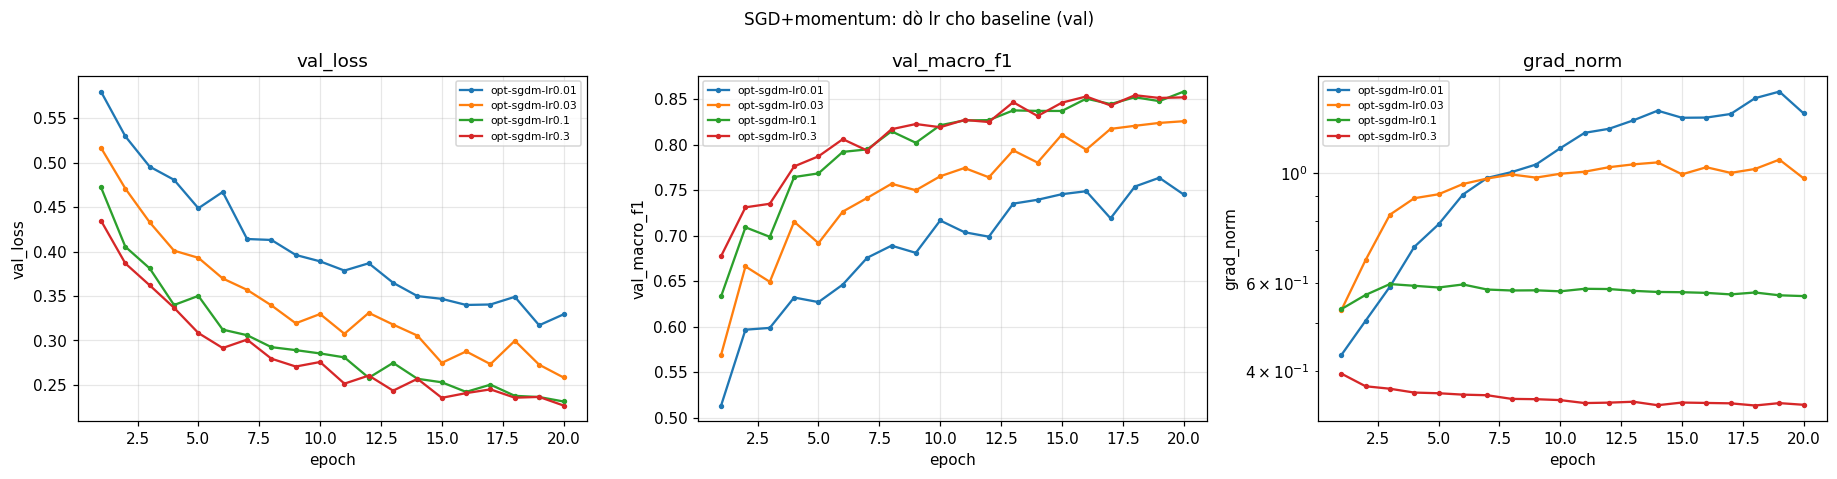

In [6]:
import pandas as pd

def R(cfg, keep_state=False, show=True):
    """Chạy (hoặc nạp lại) một cấu hình. SMOKE: 2 epoch để kiểm tra code."""
    if SMOKE:
        cfg = {**cfg, "epochs": min(cfg.get("epochs", 20), 2)}
    return run_or_load(cfg, data, OUT_DIR, ckpt_dir=CKPT_DIR, keep_state=keep_state, force=FORCE_RERUN, show=show)

def table(results, base_mean=None, noise=None):
    rows = []
    for r in results:
        s, c = r["summary"], r["cfg"]
        row = dict(exp_id=c["exp_id"], lr=c["lr"], step0=s["step0_loss"], best_ep=s["best_epoch"],
                   best_val_loss=s["best_val_loss"], train_loss=s["final_train_loss"], val_loss=s["final_val_loss"],
                   val_acc=s["val_acc"], val_F1=s["val_macro_f1"], s_per_ep=s["time_per_epoch_s"],
                   mem_MB=s["peak_mem_MB"], diverged=s["diverged"])
        if base_mean is not None and s["val_macro_f1"] is not None:
            row["ΔF1_vs_base"] = s["val_macro_f1"] - base_mean
            if noise is not None:
                row["vượt 2σ?"] = "Có" if abs(row["ΔF1_vs_base"]) > noise else "Không"
        rows.append(row)
    df = pd.DataFrame(rows).set_index("exp_id")
    with pd.option_context("display.float_format", "{:.4f}".format, "display.width", 200):
        display(df)
    return df

BASE = {**DEFAULT_CFG}
LR_GRID = [0.01, 0.03, 0.1, 0.3]
sweep = [R({**BASE, "exp_id": f"opt-sgdm-lr{lr:g}", "group": "optimizer", "lr": lr,
            "description": f"SGD+momentum 0.9, lr={lr:g} (dò lr cho baseline)"}, show=False) for lr in LR_GRID]
df_sweep = table(sweep)
ok = [r for r in sweep if not r["summary"]["diverged"]]
BASE_LR = max(ok, key=lambda r: r["summary"]["val_macro_f1"])["cfg"]["lr"]
print("lr chọn cho baseline (theo val macro-F1):", BASE_LR)
plot_compare(sweep, ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_baseline_lr.png",
             "SGD+momentum: dò lr cho baseline (val)")
from IPython.display import Image, display
display(Image(f"{OUT_DIR}/figures/compare_baseline_lr.png", width=950))

[base-s1] ep  1  train 0.4707  val 0.4722  acc 0.7960  F1 0.6335  |g| 0.532  1.2s
[base-s1] ep  2  train 0.3971  val 0.4054  acc 0.8268  F1 0.7093  |g| 0.568  1.2s
[base-s1] ep  3  train 0.3736  val 0.3811  acc 0.8438  F1 0.6988  |g| 0.598  1.2s
[base-s1] ep  4  train 0.3334  val 0.3399  acc 0.8575  F1 0.7645  |g| 0.593  1.2s
[base-s1] ep  5  train 0.3380  val 0.3501  acc 0.8537  F1 0.7685  |g| 0.588  1.2s
[base-s1] ep  6  train 0.3006  val 0.3122  acc 0.8715  F1 0.7921  |g| 0.597  1.3s
[base-s1] ep  7  train 0.2930  val 0.3060  acc 0.8732  F1 0.7949  |g| 0.583  1.5s
[base-s1] ep  8  train 0.2829  val 0.2925  acc 0.8784  F1 0.8147  |g| 0.580  1.5s
[base-s1] ep  9  train 0.2745  val 0.2892  acc 0.8817  F1 0.8021  |g| 0.581  1.2s
[base-s1] ep 10  train 0.2682  val 0.2854  acc 0.8845  F1 0.8214  |g| 0.578  1.2s
[base-s1] ep 11  train 0.2623  val 0.2810  acc 0.8878  F1 0.8267  |g| 0.585  1.2s
[base-s1] ep 12  train 0.2386  val 0.2581  acc 0.8960  F1 0.8270  |g| 0.584  1.2s
[base-s1] ep 13 

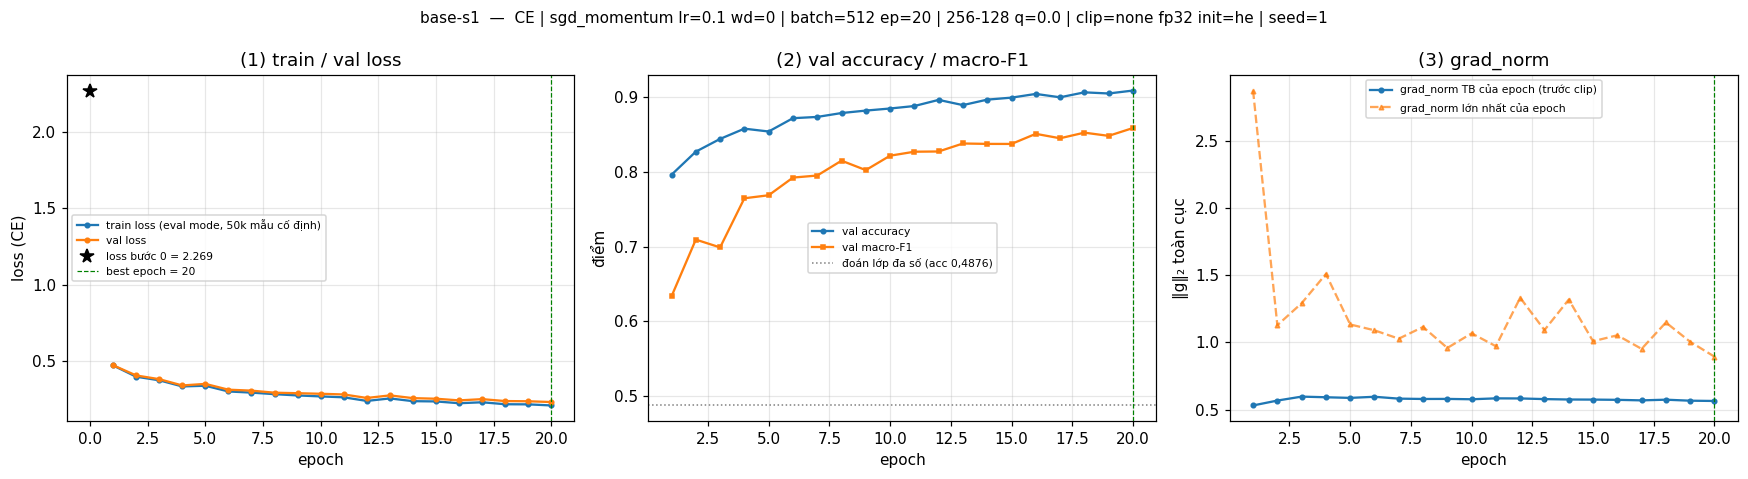

[base-s2] ep  1  train 0.4749  val 0.4820  acc 0.7936  F1 0.6298  |g| 0.520  1.2s
[base-s2] ep  2  train 0.4053  val 0.4107  acc 0.8282  F1 0.7022  |g| 0.552  1.2s
[base-s2] ep  3  train 0.3638  val 0.3698  acc 0.8440  F1 0.7392  |g| 0.553  1.2s
[base-s2] ep  4  train 0.3454  val 0.3533  acc 0.8516  F1 0.7479  |g| 0.556  1.2s
[base-s2] ep  5  train 0.3254  val 0.3328  acc 0.8632  F1 0.7739  |g| 0.550  1.2s
[base-s2] ep  6  train 0.3274  val 0.3366  acc 0.8610  F1 0.7799  |g| 0.559  1.1s
[base-s2] ep  7  train 0.2909  val 0.3054  acc 0.8774  F1 0.7946  |g| 0.569  1.3s
[base-s2] ep  8  train 0.2671  val 0.2818  acc 0.8857  F1 0.8061  |g| 0.567  1.3s
[base-s2] ep  9  train 0.2572  val 0.2680  acc 0.8928  F1 0.8201  |g| 0.559  1.5s
[base-s2] ep 10  train 0.2619  val 0.2763  acc 0.8877  F1 0.7975  |g| 0.562  1.1s
[base-s2] ep 11  train 0.2611  val 0.2739  acc 0.8900  F1 0.8154  |g| 0.555  1.2s
[base-s2] ep 12  train 0.2599  val 0.2782  acc 0.8904  F1 0.8235  |g| 0.559  1.2s
[base-s2] ep 13 

,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged
exp_id,,,,,,,,,,,
base-s1,0.1000,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2641,172.8032,False
base-s2,0.1000,1.9782,20,0.2261,0.2032,0.2261,0.9098,0.8552,1.2441,172.8032,False
base-s3,0.1000,1.9005,19,0.2275,0.2286,0.2532,0.9090,0.8551,1.2398,172.8032,False


val macro-F1 baseline: 0.8562 ± 0.0019 (σ mẫu, 3 seed)  -> ngưỡng nhiễu 2σ = 0.0037
val accuracy baseline: 0.9091 ± 0.0007
tái lập: opt-sgdm-lr0.1 F1 = 0.8584  vs  base-s1 F1 = 0.8584


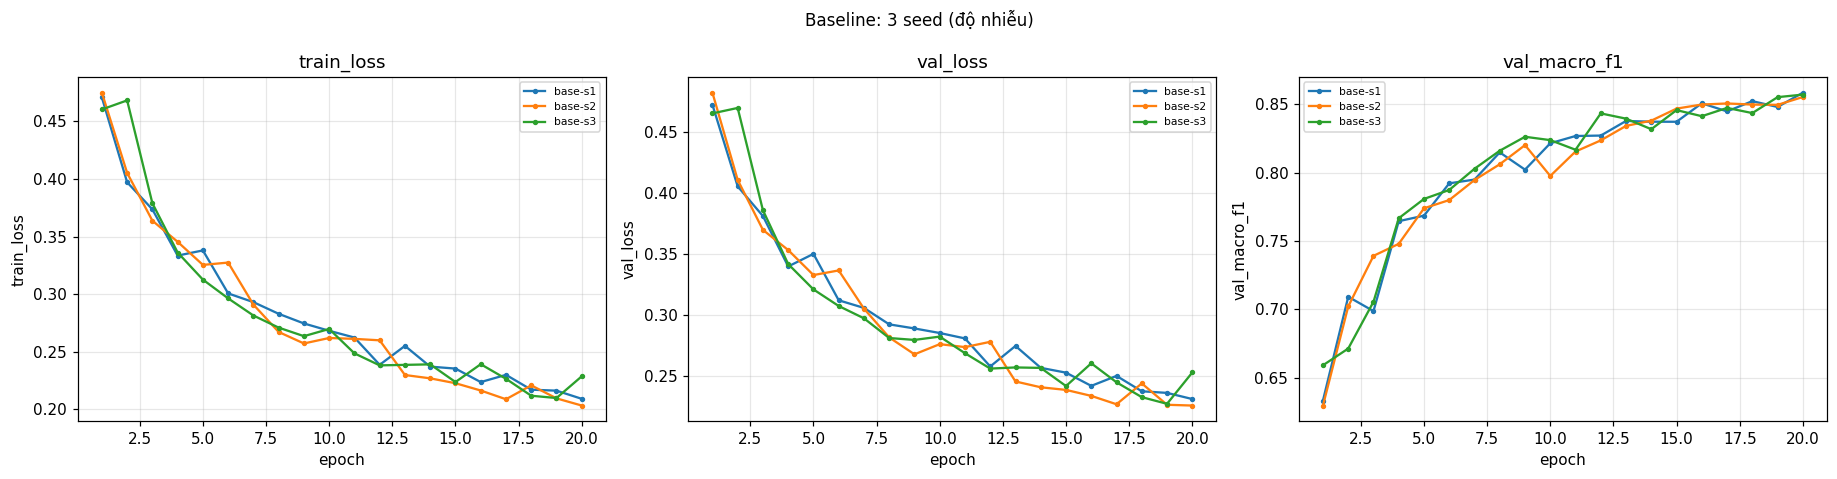

In [7]:
# Baseline với 3 seed để đo độ nhiễu. base-s1 trùng cấu hình với opt-sgdm-lr<BASE_LR> -> kiểm tra tái lập.
BASE = {**DEFAULT_CFG, "lr": BASE_LR}
base_runs = []
for s in (1, 2, 3):
    base_runs.append(R({**BASE, "seed": s, "exp_id": f"base-s{s}", "group": "baseline",
                        "description": f"Baseline M-base, seed {s}"}, keep_state=(s == 1), show=(s == 1)))
df_base = table(base_runs)
f1s = np.array([r["summary"]["val_macro_f1"] for r in base_runs])
accs = np.array([r["summary"]["val_acc"] for r in base_runs])
BASE_F1, BASE_SD = f1s.mean(), f1s.std(ddof=1)
NOISE = 2 * BASE_SD
print(f"val macro-F1 baseline: {BASE_F1:.4f} ± {BASE_SD:.4f} (σ mẫu, 3 seed)  -> ngưỡng nhiễu 2σ = {NOISE:.4f}")
print(f"val accuracy baseline: {accs.mean():.4f} ± {accs.std(ddof=1):.4f}")
same = [r for r in sweep if r["cfg"]["lr"] == BASE_LR][0]["summary"]["val_macro_f1"]
print(f"tái lập: opt-sgdm-lr{BASE_LR:g} F1 = {same:.4f}  vs  base-s1 F1 = {base_runs[0]['summary']['val_macro_f1']:.4f}")
plot_compare(base_runs, ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_baseline_seeds.png",
             "Baseline: 3 seed (độ nhiễu)")
display(Image(f"{OUT_DIR}/figures/compare_baseline_seeds.png", width=950))

**Nhận xét baseline (đối chiếu sau khi chạy):**
- Dò lr (SGD+momentum 0,9, seed 1): lr 0,01 → val F1 0,7637; 0,03 → 0,8258; **0,1 → 0,8584**; 0,3 → 0,8521. Chọn **lr = 0,1** bằng val. Dự đoán "0,01 quá chậm" đúng; "0,3 dao động" chỉ đúng một phần: 0,3 không phân kỳ, val loss còn thấp nhất (0,2269) nhưng macro-F1 thấp hơn 0,1 (0,8521 vs 0,8584; một seed, chênh 0,006 ≈ 1,7 × 2σ — chưa chắc chắn).
- 3 seed: val macro-F1 **0,8562 ± 0,0019**, val acc **0,9091 ± 0,0007** → ngưỡng nhiễu 2σ = **0,0037** (macro-F1). Vượt xa mốc "đoán lớp đa số" (0,4876).
- Hình dạng đường cong (`base-s1.png`): train và val loss cùng giảm đều đến epoch 20 (val 0,472 → 0,231), best epoch là 20/20/19, khoảng cách val − train chỉ ≈ 0,02 → **chưa quá khớp, chưa hội tụ hẳn** (còn thiếu khớp/thiếu thời gian). grad_norm trung bình ổn định ≈ 0,53–0,60, chỉ có một gai 2,87 ở epoch 1.
- `opt-sgdm-lr0.1` và `base-s1` cho cùng F1 0,8584 → pipeline tái lập được với cùng seed.

## Part 3 — Thí nghiệm
Mỗi nhóm: **dự đoán trước** (viết trước khi chạy) → đổi **một** yếu tố so với baseline (cùng split, cùng 20 epoch, seed 1) → chạy → **đối chiếu**.
So sánh luôn bằng val macro-F1 của epoch có val loss thấp nhất, với ngưỡng nhiễu 2σ đo ở Part 2. Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Chủ đề 1 — Hàm mất mát: CE vs MSE (`loss-*`)
**Dự đoán trước:** MSE trên one-hot (trung bình trên mọi B·7 phần tử) cho gradient theo logit `2(z − y)/7` — bị chặn và nhỏ khi dự đoán sai nặng, trong khi CE cho `softmax(z) − y` không bão hoà.
Với cùng lr, MSE sẽ học chậm hơn rõ rệt và macro-F1 thấp hơn baseline (nhất là các lớp hiếm, vì tín hiệu gradient của chúng vốn đã nhỏ). Tăng lr ×3 cho MSE sẽ thu hẹp một phần khoảng cách.
Không so giá trị loss CE với MSE (khác thang đo), chỉ so accuracy / macro-F1 và tốc độ hội tụ.

[loss-mse] ep  1  train 0.0483  val 0.0486  acc 0.7634  F1 0.4626  |g| 0.060  1.2s
[loss-mse] ep  2  train 0.0442  val 0.0445  acc 0.7883  F1 0.5292  |g| 0.055  1.2s
[loss-mse] ep  3  train 0.0416  val 0.0420  acc 0.8020  F1 0.5465  |g| 0.063  1.2s
[loss-mse] ep  4  train 0.0398  val 0.0403  acc 0.8123  F1 0.6152  |g| 0.070  1.2s
[loss-mse] ep  5  train 0.0378  val 0.0384  acc 0.8192  F1 0.5918  |g| 0.076  1.2s
[loss-mse] ep  6  train 0.0380  val 0.0387  acc 0.8234  F1 0.6326  |g| 0.082  1.3s
[loss-mse] ep  7  train 0.0352  val 0.0359  acc 0.8344  F1 0.6534  |g| 0.085  1.3s
[loss-mse] ep  8  train 0.0344  val 0.0351  acc 0.8395  F1 0.6655  |g| 0.087  1.3s
[loss-mse] ep  9  train 0.0334  val 0.0340  acc 0.8448  F1 0.6701  |g| 0.089  1.5s
[loss-mse] ep 10  train 0.0329  val 0.0337  acc 0.8457  F1 0.6772  |g| 0.089  1.5s
[loss-mse] ep 11  train 0.0322  val 0.0330  acc 0.8513  F1 0.6834  |g| 0.094  1.4s
[loss-mse] ep 12  train 0.0322  val 0.0332  acc 0.8526  F1 0.6929  |g| 0.094  1.2s
[los

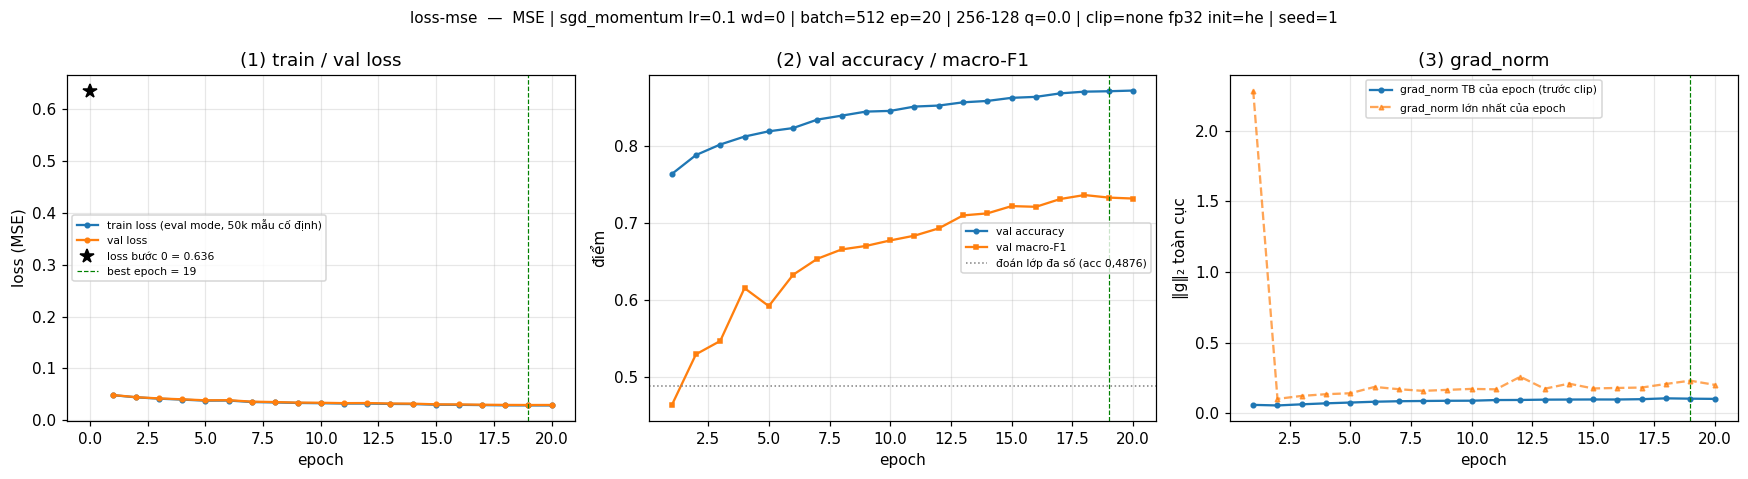

[loss-mse-lrx3] ep  1  train 0.0454  val 0.0453  acc 0.7815  F1 0.5320  |g| 0.057  1.4s
[loss-mse-lrx3] ep  2  train 0.0403  val 0.0406  acc 0.8054  F1 0.6306  |g| 0.058  1.2s
[loss-mse-lrx3] ep  3  train 0.0378  val 0.0381  acc 0.8206  F1 0.6363  |g| 0.061  1.2s
[loss-mse-lrx3] ep  4  train 0.0360  val 0.0365  acc 0.8298  F1 0.6794  |g| 0.066  1.2s
[loss-mse-lrx3] ep  5  train 0.0351  val 0.0356  acc 0.8371  F1 0.6894  |g| 0.067  1.2s
[loss-mse-lrx3] ep  6  train 0.0357  val 0.0361  acc 0.8385  F1 0.6933  |g| 0.068  1.3s
[loss-mse-lrx3] ep  7  train 0.0327  val 0.0331  acc 0.8499  F1 0.7192  |g| 0.068  1.2s
[loss-mse-lrx3] ep  8  train 0.0319  val 0.0323  acc 0.8537  F1 0.7281  |g| 0.069  1.2s
[loss-mse-lrx3] ep  9  train 0.0312  val 0.0317  acc 0.8588  F1 0.7110  |g| 0.069  1.4s
[loss-mse-lrx3] ep 10  train 0.0307  val 0.0313  acc 0.8606  F1 0.7471  |g| 0.070  1.5s
[loss-mse-lrx3] ep 11  train 0.0304  val 0.0311  acc 0.8634  F1 0.7356  |g| 0.069  1.4s
[loss-mse-lrx3] ep 12  train 0.0

,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,0.1000,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2641,172.8032,False,0.0021,Không
loss-mse,0.1000,0.6359,19,0.0294,0.0285,0.0294,0.8713,0.7329,1.2906,172.8066,False,-0.1233,Có
loss-mse-lrx3,0.3000,0.6359,20,0.0273,0.0263,0.0273,0.8831,0.7887,1.2842,172.8066,False,-0.0675,Có


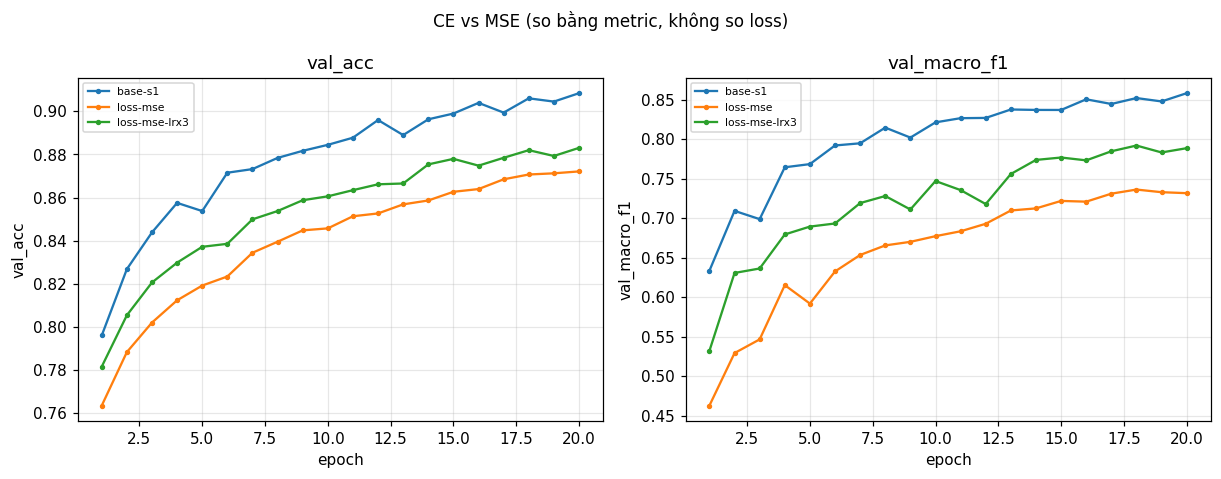

In [8]:
loss_runs = [
    R({**BASE, "exp_id": "loss-mse", "group": "loss", "loss": "mse", "description": "MSE trên one-hot (mean trên B*7), cùng lr baseline"}),
    R({**BASE, "exp_id": "loss-mse-lrx3", "group": "loss", "loss": "mse", "lr": 3 * BASE_LR,
       "description": "MSE, lr x3 (đổi 2 yếu tố: loss + lr, để bù gradient nhỏ của MSE)"}, show=False),
]
table([base_runs[0]] + loss_runs, BASE_F1, NOISE)
plot_compare([base_runs[0]] + loss_runs, ["val_acc", "val_macro_f1"], f"{OUT_DIR}/figures/compare_loss.png", "CE vs MSE (so bằng metric, không so loss)")
display(Image(f"{OUT_DIR}/figures/compare_loss.png", width=800))

**Đối chiếu (loss):** khớp dự đoán.
- `loss-mse` (cùng lr 0,1): val macro-F1 **0,7329** vs baseline 0,8562 ± 0,0019 → kém 0,123, vượt xa 2σ; accuracy 0,8713 vs 0,9091. Đường F1 (`compare_loss.png`) tăng chậm hơn hẳn từ epoch đầu (0,46 vs 0,63 ở epoch 1).
- `loss-mse-lrx3` (lr 0,3, đổi 2 yếu tố có chủ đích): 0,7887 — tăng lr thu hẹp được một phần khoảng cách nhưng vẫn kém CE 0,068.
- Cơ chế: gradient của MSE theo logit là 2(z − y)/7, bị chặn và nhỏ (grad_norm trung bình chỉ 0,087 so với 0,577 của CE), không tăng khi dự đoán sai nặng; CE có gradient softmax(z) − y không bão hoà nên lớp sai được đẩy mạnh hơn. Lớp hiếm chịu thiệt nhiều nhất nên macro-F1 tụt mạnh hơn accuracy (−0,12 vs −0,04).
- Không so giá trị loss (MSE ≈ 0,03 vs CE ≈ 0,23 là khác thang đo). Hạn chế: 1 seed mỗi cấu hình MSE, nhưng chênh lệch lớn gấp hàng chục lần 2σ.

### Chủ đề 2 — Bộ tối ưu hoá (`opt-*`)
**Dự đoán trước:** SGD không momentum cần lr lớn hơn ~10 lần SGD+momentum mới đi được quãng đường tương đương (bước hiệu dụng của momentum ≈ lr/(1−μ) = 10·lr), nên ở cùng lr nó chậm hơn.
Adam/AdamW chuẩn hoá bước theo √v̂ của từng tham số nên ít nhạy với tỉ lệ gradient và hội tụ nhanh hơn ở vài epoch đầu; ở lr tốt nhất của mỗi bộ, Adam có thể nhỉnh hơn SGD+momentum
nhưng khác biệt có thể không vượt 2σ. AdamW với `weight_decay=0` phải cho kết quả **trùng** Adam (cùng seed).
Mỗi bộ thử 3 lr cách nhau ~3 lần, so ở lr tốt nhất (theo val macro-F1) của từng bộ.

[opt-sgd-lr0.03] ep  1  train 0.6463  val 0.6492  acc 0.7299  F1 0.4220  |g| 0.423  1.2s
[opt-sgd-lr0.03] ep  2  train 0.6030  val 0.6061  acc 0.7452  F1 0.5091  |g| 0.408  1.1s
[opt-sgd-lr0.03] ep  3  train 0.5770  val 0.5810  acc 0.7567  F1 0.5087  |g| 0.444  1.1s
[opt-sgd-lr0.03] ep  4  train 0.5673  val 0.5718  acc 0.7566  F1 0.5548  |g| 0.470  1.1s
[opt-sgd-lr0.03] ep  5  train 0.5443  val 0.5488  acc 0.7690  F1 0.5576  |g| 0.502  1.1s
[opt-sgd-lr0.03] ep  6  train 0.5323  val 0.5369  acc 0.7725  F1 0.5734  |g| 0.541  1.1s
[opt-sgd-lr0.03] ep  7  train 0.5179  val 0.5222  acc 0.7771  F1 0.5968  |g| 0.565  1.2s
[opt-sgd-lr0.03] ep  8  train 0.5044  val 0.5086  acc 0.7841  F1 0.5983  |g| 0.606  1.1s
[opt-sgd-lr0.03] ep  9  train 0.4925  val 0.4964  acc 0.7904  F1 0.6033  |g| 0.649  1.2s
[opt-sgd-lr0.03] ep 10  train 0.4875  val 0.4915  acc 0.7891  F1 0.6179  |g| 0.698  1.3s
[opt-sgd-lr0.03] ep 11  train 0.4755  val 0.4798  acc 0.7975  F1 0.6121  |g| 0.740  1.3s
[opt-sgd-lr0.03] ep 1

,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
opt-sgdm-lr0.01,0.0100,2.2691,19,0.3171,0.3185,0.3294,0.8716,0.7637,1.2697,172.8032,False,-0.0925,Có
opt-sgdm-lr0.03,0.0300,2.2691,20,0.2584,0.2431,0.2584,0.8959,0.8258,1.2526,172.8032,False,-0.0304,Có
opt-sgdm-lr0.1,0.1000,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2616,172.8032,False,0.0021,Không
opt-sgdm-lr0.3,0.3000,2.2691,20,0.2269,0.2002,0.2269,0.9096,0.8521,1.2511,172.8032,False,-0.0042,Có
opt-sgd-lr0.03,0.0300,2.2691,18,0.4307,0.4281,0.4337,0.8203,0.6642,1.1727,172.6201,False,-0.1920,Có
opt-sgd-lr0.1,0.1000,2.2691,18,0.3429,0.4057,0.4147,0.8580,0.7397,1.2082,172.6201,False,-0.1165,Có
opt-sgd-lr0.3,0.3000,2.2691,19,0.2890,0.3412,0.3581,0.8809,0.8008,1.2230,172.6201,False,-0.0554,Có
opt-adam-lr0.0003,0.0003,2.2691,20,0.3080,0.2979,0.3080,0.8761,0.7955,1.3717,172.9863,False,-0.0607,Có
opt-adam-lr0.001,0.0010,2.2691,18,0.2420,0.2269,0.2491,0.9033,0.8437,1.4022,172.9863,False,-0.0125,Có



Mỗi bộ tối ưu ở lr tốt nhất của nó (theo val macro-F1):


,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
opt-sgdm-lr0.1,0.1000,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2616,172.8032,False,0.0021,Không
opt-sgd-lr0.3,0.3000,2.2691,19,0.2890,0.3412,0.3581,0.8809,0.8008,1.2230,172.6201,False,-0.0554,Có
opt-adam-lr0.003,0.0030,2.2691,18,0.2101,0.1828,0.2110,0.9178,0.8683,1.4060,172.9863,False,0.0121,Có
opt-adamw-lr0.003,0.0030,2.2691,20,0.2131,0.1902,0.2131,0.9137,0.8757,1.4166,172.9863,False,0.0195,Có


Adam lr=1e-3 F1 = 0.843695  |  AdamW wd=0 lr=1e-3 F1 = 0.843695


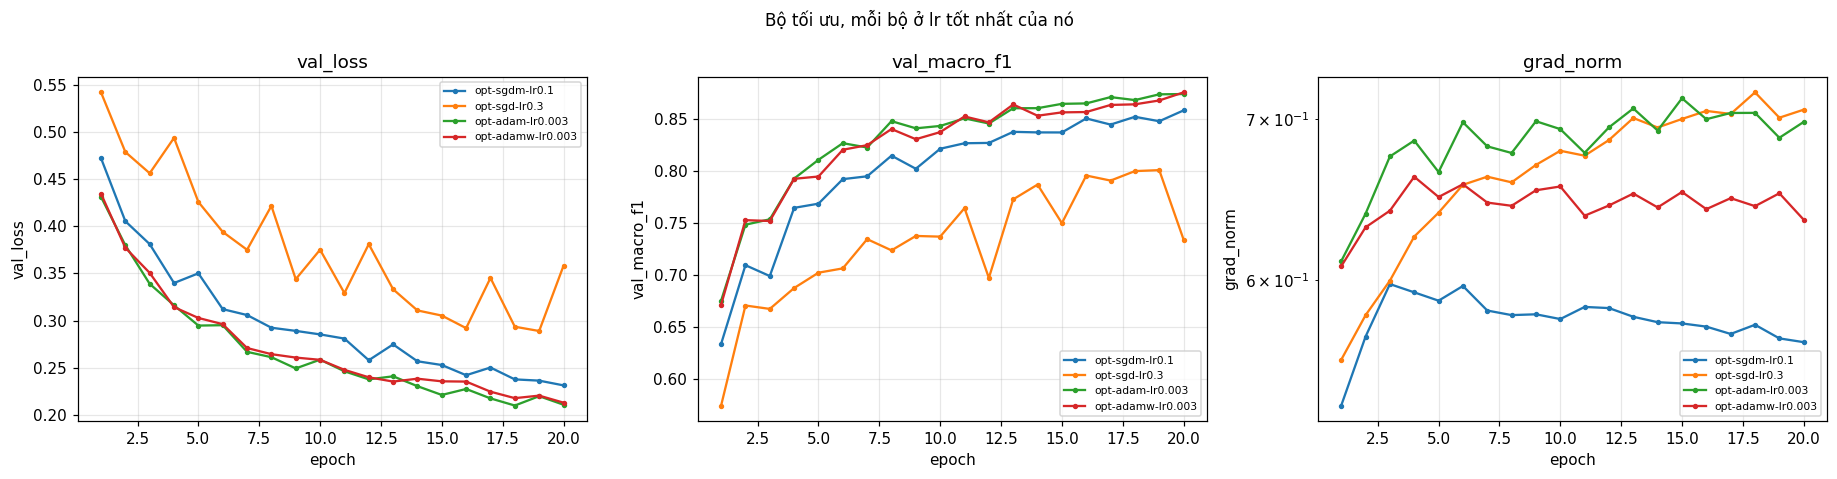

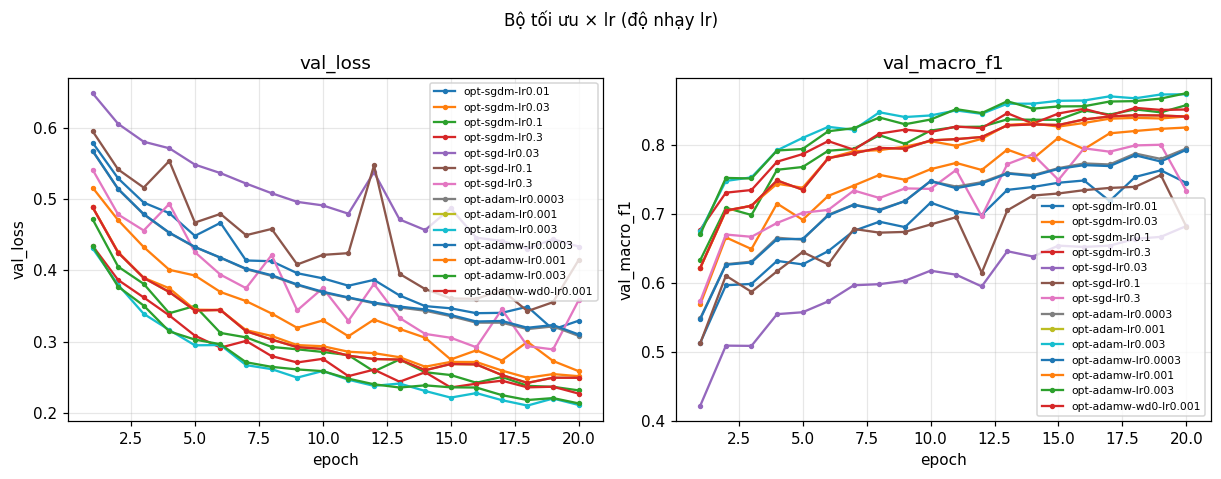

In [9]:
opt_grid = {"sgd": [0.03, 0.1, 0.3], "adam": [3e-4, 1e-3, 3e-3], "adamw": [3e-4, 1e-3, 3e-3]}
short = {"sgd": "sgd", "adam": "adam", "adamw": "adamw"}
opt_runs = {"sgd_momentum": sweep}
for name, lrs in opt_grid.items():
    opt_runs[name] = [R({**BASE, "exp_id": f"opt-{short[name]}-lr{lr:g}", "group": "optimizer", "optimizer": name, "lr": lr,
                         "weight_decay": 0.01 if name == "adamw" else 0.0,
                         "description": f"{name}, lr={lr:g}" + (", wd=0.01 (tách riêng)" if name == "adamw" else "")}, show=False)
                      for lr in lrs]
adamw_wd0 = R({**BASE, "exp_id": "opt-adamw-wd0-lr0.001", "group": "optimizer", "optimizer": "adamw", "lr": 1e-3, "weight_decay": 0.0,
               "description": "AdamW wd=0, lr=1e-3: kiểm chứng trùng Adam"}, show=False)
all_opt = [r for v in opt_runs.values() for r in v] + [adamw_wd0]
df_opt = table(all_opt, BASE_F1, NOISE)

best_opt = {k: max([r for r in v if not r["summary"]["diverged"]], key=lambda r: r["summary"]["val_macro_f1"]) for k, v in opt_runs.items()}
print("\nMỗi bộ tối ưu ở lr tốt nhất của nó (theo val macro-F1):")
table(list(best_opt.values()), BASE_F1, NOISE)
a = [r for r in opt_runs["adam"] if r["cfg"]["lr"] == 1e-3][0]["summary"]
print(f"Adam lr=1e-3 F1 = {a['val_macro_f1']:.6f}  |  AdamW wd=0 lr=1e-3 F1 = {adamw_wd0['summary']['val_macro_f1']:.6f}")

plot_compare(list(best_opt.values()), ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_optimizer.png",
             "Bộ tối ưu, mỗi bộ ở lr tốt nhất của nó")
plot_compare(all_opt, ["val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_optimizer_lr.png", "Bộ tối ưu × lr (độ nhạy lr)")
display(Image(f"{OUT_DIR}/figures/compare_optimizer.png", width=950))
display(Image(f"{OUT_DIR}/figures/compare_optimizer_lr.png", width=950))

**Đối chiếu (optimizer):** phần lớn khớp dự đoán.
- Mỗi bộ ở lr tốt nhất (theo val): SGD (lr 0,3) **0,8008**; SGD+momentum (lr 0,1) **0,8584**; Adam (lr 3e-3) **0,8683**; AdamW (lr 3e-3, wd 0,01) **0,8757**. So với baseline TB 0,8562: SGD kém 0,055 (vượt 2σ); Adam +0,012 và AdamW +0,020 (vượt 2σ = 0,0037, nhưng mỗi cấu hình chỉ 1 seed).
- Độ nhạy lr (`compare_optimizer_lr.png`): SGD thuần cần lr lớn nhất trong lưới (0,3) và vẫn chưa đủ — tốt nhất của nó ≈ SGD+momentum ở lr 0,03 (0,8258), đúng với lập luận bước hiệu dụng của momentum ≈ lr/(1−μ) = 10·lr. Adam/AdamW tăng đều theo lr trong lưới (3e-4: 0,79 → 1e-3: 0,84 → 3e-3: 0,87); lr tốt nhất nằm ở biên lưới nên có thể còn tốt hơn ở lr cao hơn (hạn chế).
- `opt-adamw-wd0-lr0.001` cho **đúng** F1 0,8437 như `opt-adam-lr0.001` → với weight_decay = 0, AdamW ≡ Adam (đã kiểm chứng).
- AdamW > Adam ở lr 3e-3 (0,8757 vs 0,8683): suy giảm trọng số tách riêng không bị chia cho √v̂ nên tác dụng đều trên mọi tham số. Chênh 0,0074 ≈ 2× ngưỡng nhiễu nhưng chỉ 1 seed → bằng chứng yếu.
- Khi không chỉnh lr công bằng, kết luận đảo chiều được: so Adam ở lr 3e-4 (0,7955) với SGD+momentum ở lr 0,1 (0,8584) thì "SGD+momentum thắng"; so ở lr tốt nhất của mỗi bộ thì Adam/AdamW thắng. Ở cùng lr 0,03, SGD+momentum hơn SGD thuần 0,16 (0,8258 vs 0,6642).

### Chủ đề 3 — Hyper-parameter (`hp-*`)
**Dự đoán trước:**
- *Batch*: cùng 20 epoch, batch 128 có 4× số bước cập nhật so với 512 → học được nhiều hơn (F1 cao hơn) nhưng mỗi epoch chậm hơn nhiều; batch 2048 chỉ có 1/4 số bước → kém hơn ở cùng lr.
  Tăng lr ×4 cho batch 2048 (quy tắc tăng lr theo lô, không khởi động) sẽ bù lại phần lớn khoảng cách, nhưng có rủi ro dao động ở đầu.
- *Độ rộng/độ sâu*: M-wide (161k tham số) và M-deep có năng lực lớn hơn; vì baseline chưa quá khớp (dự đoán) nên chúng sẽ nhỉnh hơn baseline.
- *Weight decay 1e-4*: mô hình chưa quá khớp nên gần như không đổi (trong nhiễu).
- *40 epoch*: baseline 20 epoch chưa hội tụ hẳn → 40 epoch sẽ tăng F1 rõ rệt.

[hp-batch128] ep  1  train 0.4311  val 0.4354  acc 0.8142  F1 0.6264  |g| 0.586  4.7s
[hp-batch128] ep  2  train 0.3860  val 0.3916  acc 0.8351  F1 0.7461  |g| 0.596  5.1s
[hp-batch128] ep  3  train 0.3429  val 0.3479  acc 0.8585  F1 0.7670  |g| 0.600  4.7s
[hp-batch128] ep  4  train 0.3136  val 0.3246  acc 0.8658  F1 0.7856  |g| 0.597  4.9s
[hp-batch128] ep  5  train 0.3008  val 0.3124  acc 0.8732  F1 0.7928  |g| 0.601  5.0s
[hp-batch128] ep  6  train 0.2774  val 0.2871  acc 0.8828  F1 0.8183  |g| 0.601  5.0s
[hp-batch128] ep  7  train 0.2840  val 0.2997  acc 0.8775  F1 0.8080  |g| 0.597  5.2s
[hp-batch128] ep  8  train 0.2712  val 0.2847  acc 0.8868  F1 0.8289  |g| 0.593  4.7s
[hp-batch128] ep  9  train 0.2578  val 0.2757  acc 0.8897  F1 0.8224  |g| 0.591  4.6s
[hp-batch128] ep 10  train 0.2433  val 0.2626  acc 0.8945  F1 0.8276  |g| 0.588  5.3s
[hp-batch128] ep 11  train 0.2434  val 0.2607  acc 0.8970  F1 0.8280  |g| 0.587  4.6s
[hp-batch128] ep 12  train 0.2347  val 0.2536  acc 0.8

,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,0.1000,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2641,172.8032,False,0.0021,Không
hp-batch128,0.1000,2.2691,18,0.2263,0.2028,0.2293,0.9116,0.8563,4.8898,172.7725,False,0.0000,Không
hp-batch2048,0.1000,2.2691,18,0.2892,0.2771,0.2930,0.8830,0.8090,0.3493,173.0493,False,-0.0472,Có
hp-batch2048-lrx4,0.4000,2.2691,18,0.2430,0.2193,0.2443,0.9032,0.8465,0.3237,173.0493,False,-0.0098,Có
hp-wide,0.1000,1.9182,19,0.2021,0.1758,0.2043,0.9209,0.8725,1.2802,190.1011,False,0.0162,Có
hp-deep,0.1000,1.9099,20,0.1964,0.1680,0.1964,0.9222,0.8719,1.4272,172.8940,False,0.0157,Có
hp-wd1e-4,0.1000,2.2691,20,0.2625,0.2474,0.2625,0.8946,0.8350,1.2676,172.8032,False,-0.0213,Có
hp-ep40,0.1000,2.2691,36,0.2009,0.1928,0.2282,0.9227,0.8743,1.2351,172.8032,False,0.0181,Có


số bước cập nhật / epoch: {'base-s1': 727, 'hp-batch128': 2906, 'hp-batch2048': 182, 'hp-batch2048-lrx4': 182}


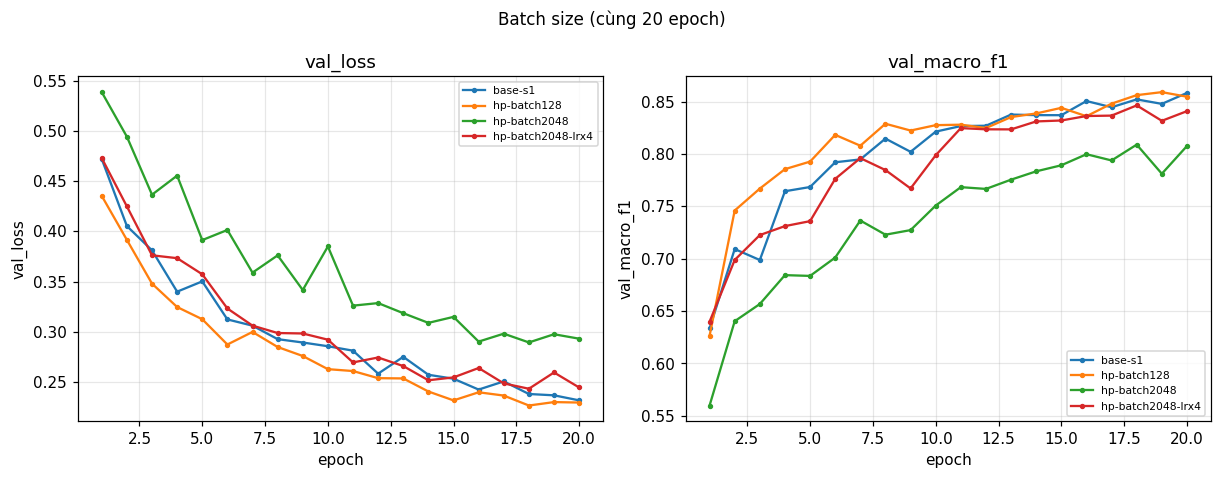

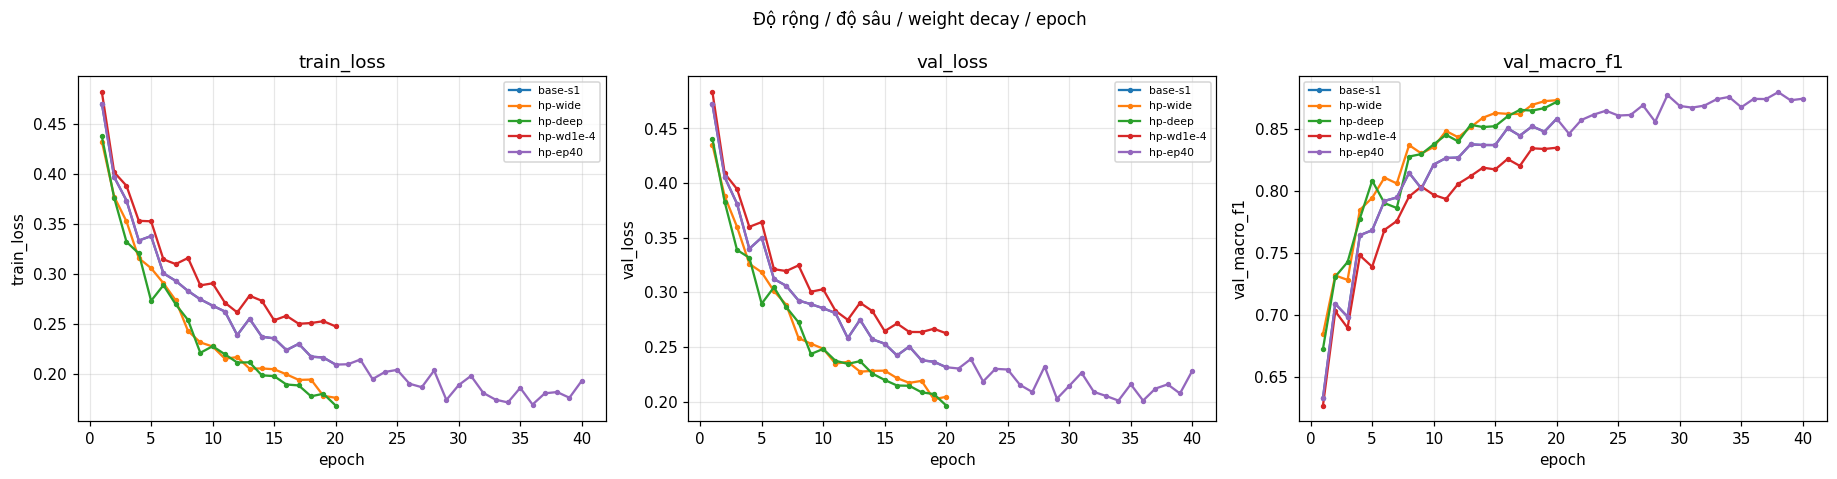

In [10]:
hp_runs = [
    R({**BASE, "exp_id": "hp-batch128", "group": "hparam", "batch": 128, "description": "batch 128 (4x số bước), cùng lr"}, show=False),
    R({**BASE, "exp_id": "hp-batch2048", "group": "hparam", "batch": 2048, "description": "batch 2048 (1/4 số bước), cùng lr"}, show=False),
    R({**BASE, "exp_id": "hp-batch2048-lrx4", "group": "hparam", "batch": 2048, "lr": 4 * BASE_LR,
       "description": "batch 2048, lr x4 (quy tắc tăng lr theo lô, không warmup) — đổi 2 yếu tố có chủ đích"}, show=False),
    R({**BASE, "exp_id": "hp-wide", "group": "hparam", "hidden": (512, 256), "description": "M-wide 54-512-256-7"}, show=False),
    R({**BASE, "exp_id": "hp-deep", "group": "hparam", "hidden": (256, 128, 64), "description": "M-deep 54-256-128-64-7"}, show=False),
    R({**BASE, "exp_id": "hp-wd1e-4", "group": "hparam", "weight_decay": 1e-4, "description": "weight_decay 1e-4 (L2 trong SGD)"}, show=False),
    R({**BASE, "exp_id": "hp-ep40", "group": "hparam", "epochs": 40, "description": "40 epoch thay vì 20"}, show=False),
]
df_hp = table([base_runs[0]] + hp_runs, BASE_F1, NOISE)
print("số bước cập nhật / epoch:", {r["cfg"]["exp_id"]: r["summary"].get("steps_per_epoch") for r in [base_runs[0]] + hp_runs[:3]})
plot_compare([base_runs[0]] + hp_runs[:3], ["val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_batch.png", "Batch size (cùng 20 epoch)")
plot_compare([base_runs[0]] + hp_runs[3:], ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_hparam.png", "Độ rộng / độ sâu / weight decay / epoch")
display(Image(f"{OUT_DIR}/figures/compare_batch.png", width=800))
display(Image(f"{OUT_DIR}/figures/compare_hparam.png", width=950))

**Đối chiếu (hparam):** khác dự đoán ở batch 128 và weight decay.
- *Batch* (cùng lr 0,1, 20 epoch): batch 128 (2 906 bước/epoch) **0,8563** ≈ baseline (trong nhiễu) dù có 4× số bước, và chậm gấp ~3,9 lần (4,89 vs 1,26 s/epoch) → **sai dự đoán**: với SGD+momentum, lô nhỏ ở cùng lr cho gradient nhiễu hơn, lợi ích từ thêm bước bị nhiễu triệt tiêu. Batch 2048 (182 bước/epoch) **0,8090** — kém 0,047 do ít bước (đúng dự đoán), nhưng nhanh 3,6× (0,35 s/epoch). Tăng lr ×4 cho batch 2048 (quy tắc tăng lr theo lô, không warmup) → **0,8465**, lấy lại ~75% khoảng cách, đúng dự đoán; không phân kỳ dù không warmup.
- *Độ rộng/độ sâu*: M-wide **0,8725** (+0,016), M-deep **0,8719** (+0,016), đều vượt 2σ → baseline thiếu năng lực/chưa khớp đủ, đúng dự đoán; thời gian/epoch gần như không đổi (1,28 / 1,43 s) vì GPU chưa bão hoà.
- *40 epoch*: **0,8743** (+0,018, vượt 2σ), best epoch 36 → xác nhận 20 epoch chưa hội tụ.
- *Weight decay 1e-4*: **0,8350** (−0,021, vượt 2σ) → **sai dự đoán** "không đổi": vì mô hình đang thiếu khớp, thêm chính quy hoá kéo trọng số về 0 làm học chậm hơn (val loss 0,2625 vs 0,2314).
- Hạn chế: 1 seed mỗi cấu hình.

### Chủ đề 4 — Dropout (`drop-*`)
**Dự đoán trước:** dropout là thuốc cho quá khớp. Nếu baseline chưa quá khớp (khoảng cách val − train loss nhỏ, val loss vẫn giảm ở epoch 20) thì dropout chỉ làm
mô hình học chậm hơn: q = 0,1 gần như không đổi, q = 0,3 và 0,5 làm giảm macro-F1 (vượt nhiễu), và khoảng cách train–val thu hẹp. Train loss đo ở eval mode nên không bị "phồng" giả do dropout.

[drop-0.1] ep  1  train 0.4789  val 0.4806  acc 0.7958  F1 0.6298  |g| 0.393  1.4s
[drop-0.1] ep  2  train 0.4239  val 0.4268  acc 0.8215  F1 0.7042  |g| 0.365  1.5s
[drop-0.1] ep  3  train 0.3939  val 0.3994  acc 0.8322  F1 0.6981  |g| 0.368  1.6s
[drop-0.1] ep  4  train 0.3700  val 0.3760  acc 0.8422  F1 0.7420  |g| 0.378  1.3s
[drop-0.1] ep  5  train 0.3439  val 0.3497  acc 0.8547  F1 0.7259  |g| 0.379  1.3s
[drop-0.1] ep  6  train 0.3356  val 0.3405  acc 0.8601  F1 0.7735  |g| 0.381  1.3s
[drop-0.1] ep  7  train 0.3152  val 0.3207  acc 0.8691  F1 0.7878  |g| 0.384  1.3s
[drop-0.1] ep  8  train 0.3051  val 0.3108  acc 0.8721  F1 0.7814  |g| 0.383  1.3s
[drop-0.1] ep  9  train 0.2967  val 0.3046  acc 0.8753  F1 0.7948  |g| 0.382  1.3s
[drop-0.1] ep 10  train 0.2864  val 0.2933  acc 0.8792  F1 0.8057  |g| 0.386  1.3s
[drop-0.1] ep 11  train 0.2813  val 0.2905  acc 0.8807  F1 0.8091  |g| 0.385  1.4s
[drop-0.1] ep 12  train 0.2755  val 0.2866  acc 0.8842  F1 0.8013  |g| 0.384  1.5s
[dro

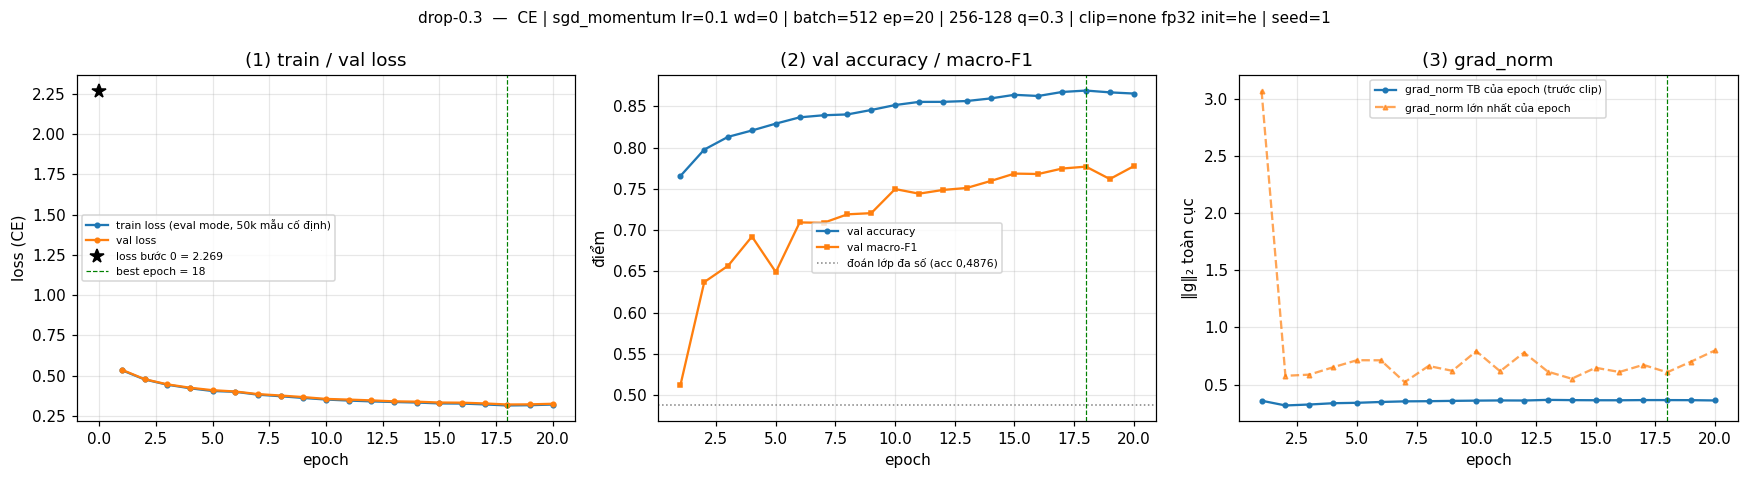

[drop-0.5] ep  1  train 0.5779  val 0.5795  acc 0.7423  F1 0.4385  |g| 0.378  1.5s
[drop-0.5] ep  2  train 0.5319  val 0.5331  acc 0.7724  F1 0.5823  |g| 0.320  1.5s
[drop-0.5] ep  3  train 0.5068  val 0.5087  acc 0.7813  F1 0.5408  |g| 0.325  1.4s
[drop-0.5] ep  4  train 0.4810  val 0.4846  acc 0.7919  F1 0.6023  |g| 0.335  1.3s
[drop-0.5] ep  5  train 0.4700  val 0.4734  acc 0.7983  F1 0.5403  |g| 0.342  1.3s
[drop-0.5] ep  6  train 0.4666  val 0.4681  acc 0.8034  F1 0.5405  |g| 0.348  1.3s
[drop-0.5] ep  7  train 0.4514  val 0.4531  acc 0.8047  F1 0.5527  |g| 0.353  1.3s
[drop-0.5] ep  8  train 0.4466  val 0.4490  acc 0.8046  F1 0.6159  |g| 0.355  1.3s
[drop-0.5] ep  9  train 0.4409  val 0.4437  acc 0.8101  F1 0.5739  |g| 0.358  1.3s
[drop-0.5] ep 10  train 0.4296  val 0.4328  acc 0.8134  F1 0.6401  |g| 0.358  1.5s
[drop-0.5] ep 11  train 0.4256  val 0.4289  acc 0.8172  F1 0.5758  |g| 0.360  1.6s
[drop-0.5] ep 12  train 0.4193  val 0.4235  acc 0.8196  F1 0.6376  |g| 0.360  1.5s
[dro

,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,0.1000,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2641,172.8032,False,0.0021,Không
drop-0.1,0.1000,2.2691,19,0.2507,0.2409,0.2521,0.8973,0.8368,1.3549,172.8032,False,-0.0194,Có
drop-0.3,0.1000,2.2691,18,0.3214,0.3213,0.3259,0.8690,0.7769,1.3579,172.8032,False,-0.0794,Có
drop-0.5,0.1000,2.2691,18,0.4048,0.4042,0.4080,0.8278,0.6630,1.3958,172.8032,False,-0.1933,Có


base-s1    gap val−train loss cuối = +0.0223
drop-0.1   gap val−train loss cuối = +0.0113
drop-0.3   gap val−train loss cuối = +0.0046
drop-0.5   gap val−train loss cuối = +0.0038


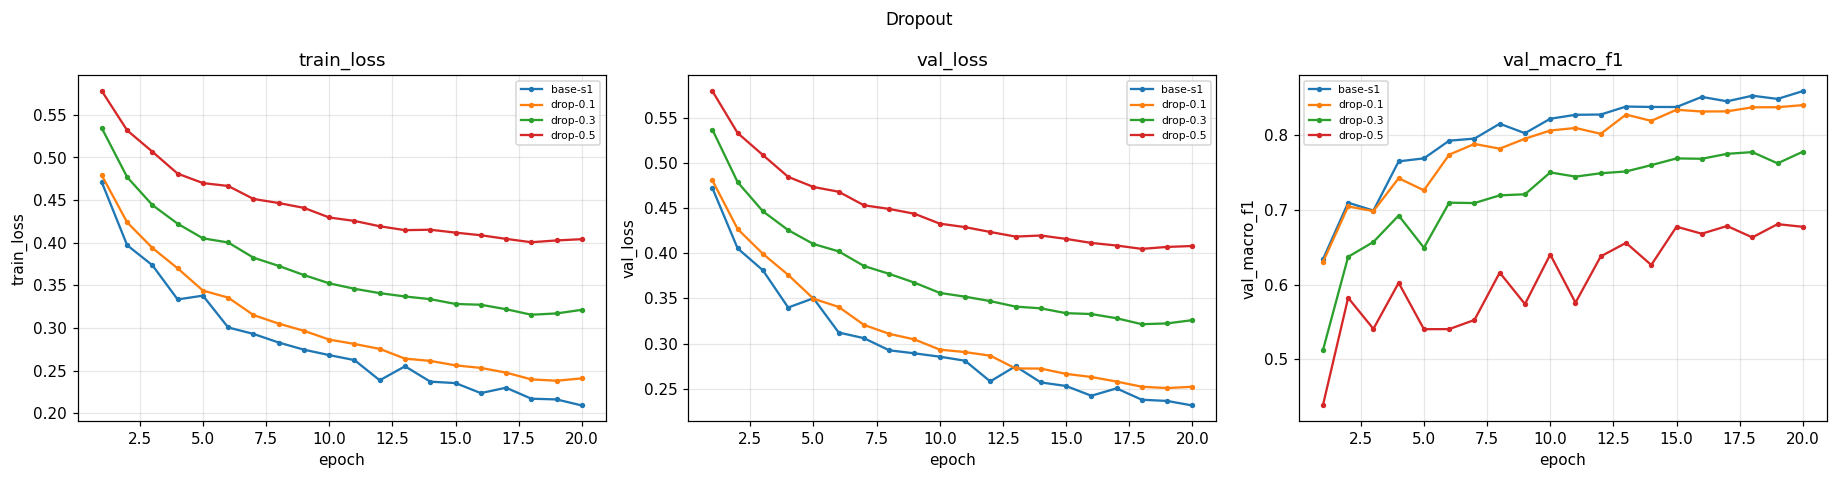

In [11]:
drop_runs = [R({**BASE, "exp_id": f"drop-{q}", "group": "dropout", "dropout": q, "description": f"dropout q={q} sau mỗi ReLU ẩn"}, show=(q == 0.3))
             for q in (0.1, 0.3, 0.5)]
df_drop = table([base_runs[0]] + drop_runs, BASE_F1, NOISE)
for r in [base_runs[0]] + drop_runs:
    s = r["summary"]
    print(f"{r['cfg']['exp_id']:10s} gap val−train loss cuối = {s['final_val_loss'] - s['final_train_loss']:+.4f}")
plot_compare([base_runs[0]] + drop_runs, ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_dropout.png", "Dropout")
display(Image(f"{OUT_DIR}/figures/compare_dropout.png", width=950))

**Đối chiếu (dropout):** khớp dự đoán, thậm chí còn rõ hơn.
- val macro-F1: q = 0,1 → **0,8368** (−0,019); q = 0,3 → **0,7769** (−0,079); q = 0,5 → **0,6630** (−0,193); đều vượt 2σ và giảm đơn điệu theo q.
- Baseline không quá khớp: khoảng cách val − train loss (train đo ở eval mode) chỉ ≈ +0,022 ở epoch 20 và val loss vẫn giảm. Dropout thu hẹp khoảng cách này về gần 0 (+0,011 / +0,005 / +0,004) nhưng bằng cách làm **cả train lẫn val loss tăng** (0,24 / 0,32 / 0,40), tức là làm mô hình thiếu khớp thêm.
- Cơ chế: dropout là chính quy hoá — thêm nhiễu và giảm năng lực hiệu dụng; chỉ có ích khi phương sai (quá khớp) là vấn đề. Ở đây vấn đề là thiên lệch/thiếu thời gian nên dropout có hại. Lớp hiếm bị ảnh hưởng nặng nhất nên macro-F1 giảm nhanh hơn accuracy.
- Nên dùng dropout khi train loss tiếp tục giảm còn val loss bắt đầu tăng (khoảng cách mở rộng), ví dụ với M-wide huấn luyện rất lâu.

### Chủ đề 5 — Gradient clipping (`clip-*`)
Chọn `c` **dựa trên grad_norm của baseline**: lấy trung vị của grad_norm trung bình theo epoch của `base-s1`, để clipping thực sự kích hoạt ở một phần đáng kể các bước
(tỉ lệ bước bị cắt được ghi trong `clip_frac`).

**Dự đoán trước:** ở lr baseline, clipping chỉ làm bước nhỏ lại ở các bước gradient lớn → kết quả gần baseline (trong nhiễu), có thể chậm hơn chút.
Ở lr cao (×10, ×30) không clip: loss dao động mạnh hoặc NaN (grad_norm có gai lớn); có clip: chuẩn bước cập nhật bị chặn ở lr·c nên huấn luyện ổn định hơn và F1 cao hơn hẳn bản không clip.

base-s1 grad_norm TB theo epoch: [0.532 0.568 0.598 0.593 0.588 0.597 0.583 0.58  0.581 0.578 0.585 0.584
 0.579 0.576 0.576 0.574 0.57  0.575 0.567 0.565]
base-s1 grad_norm max theo epoch: [2.871 1.128 1.291 1.508 1.134 1.09  1.028 1.115 0.959 1.068 0.972 1.332
 1.092 1.319 1.009 1.053 0.952 1.148 1.005 0.894]
chọn c = 0.58
[clip-0.58] ep  1  train 0.4615  val 0.4623  acc 0.8041  F1 0.6410  |g| 0.568  1.2s
[clip-0.58] ep  2  train 0.3954  val 0.4008  acc 0.8307  F1 0.7106  |g| 0.601  1.2s
[clip-0.58] ep  3  train 0.4122  val 0.4174  acc 0.8194  F1 0.7115  |g| 0.620  1.2s
[clip-0.58] ep  4  train 0.3418  val 0.3507  acc 0.8514  F1 0.7574  |g| 0.622  1.2s
[clip-0.58] ep  5  train 0.3612  val 0.3715  acc 0.8433  F1 0.7624  |g| 0.622  1.2s
[clip-0.58] ep  6  train 0.3254  val 0.3347  acc 0.8623  F1 0.7766  |g| 0.628  1.2s
[clip-0.58] ep  7  train 0.2862  val 0.2979  acc 0.8771  F1 0.7855  |g| 0.612  1.3s
[clip-0.58] ep  8  train 0.2817  val 0.2945  acc 0.8804  F1 0.8106  |g| 0.611  1.2s
[

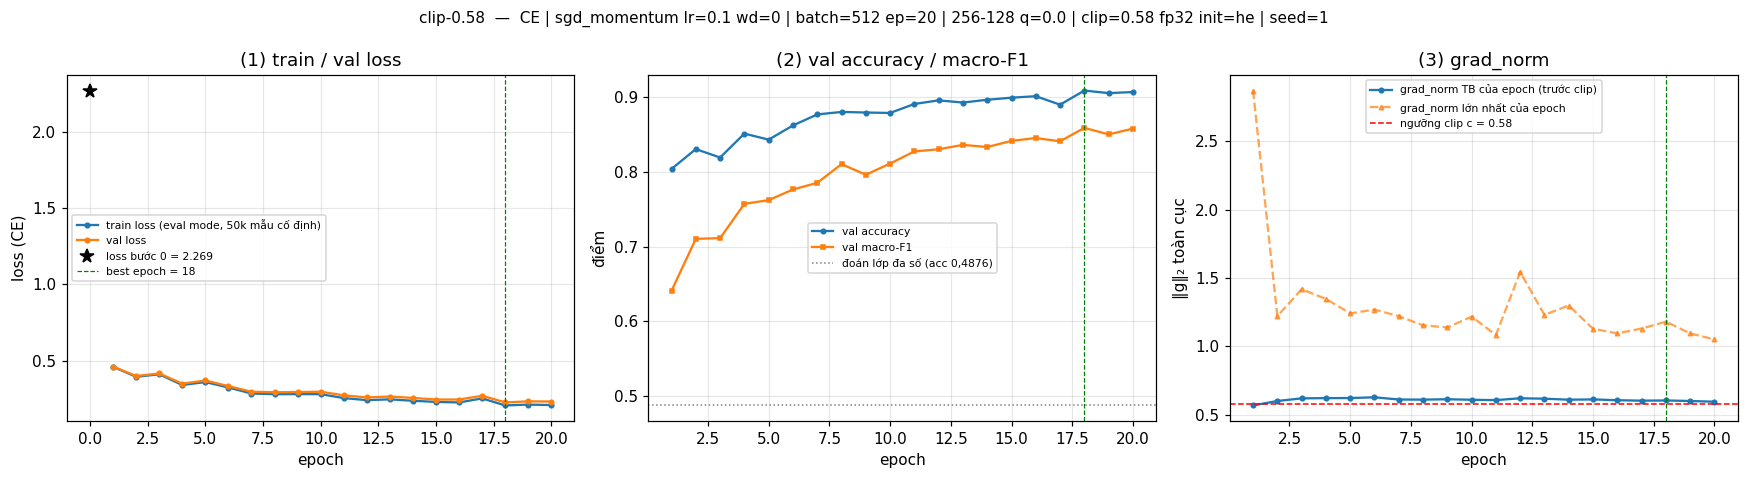

[clip-none-lrx10] ep  1  train 0.5451  val 0.5457  acc 0.7710  F1 0.5097  |g| 0.352  1.4s
[clip-none-lrx10] ep  2  train 0.5023  val 0.5035  acc 0.7913  F1 0.5653  |g| 0.256  1.2s
[clip-none-lrx10] ep  3  train 0.4801  val 0.4823  acc 0.8016  F1 0.6511  |g| 0.253  1.2s
[clip-none-lrx10] ep  4  train 0.4631  val 0.4683  acc 0.8073  F1 0.6583  |g| 0.250  1.2s
[clip-none-lrx10] ep  5  train 0.4444  val 0.4527  acc 0.8142  F1 0.6676  |g| 0.247  1.2s
[clip-none-lrx10] ep  6  train 0.4404  val 0.4489  acc 0.8141  F1 0.7004  |g| 0.249  1.2s
[clip-none-lrx10] ep  7  train 0.4006  val 0.4107  acc 0.8337  F1 0.6953  |g| 0.256  1.2s
[clip-none-lrx10] ep  8  train 0.3826  val 0.3921  acc 0.8403  F1 0.7294  |g| 0.245  1.2s
[clip-none-lrx10] ep  9  train 0.4135  val 0.4266  acc 0.8270  F1 0.7179  |g| 0.241  1.2s
[clip-none-lrx10] ep 10  train 0.3840  val 0.3905  acc 0.8441  F1 0.7376  |g| 0.244  1.3s
[clip-none-lrx10] ep 11  train 0.3870  val 0.3979  acc 0.8462  F1 0.7389  |g| 0.244  1.4s
[clip-none

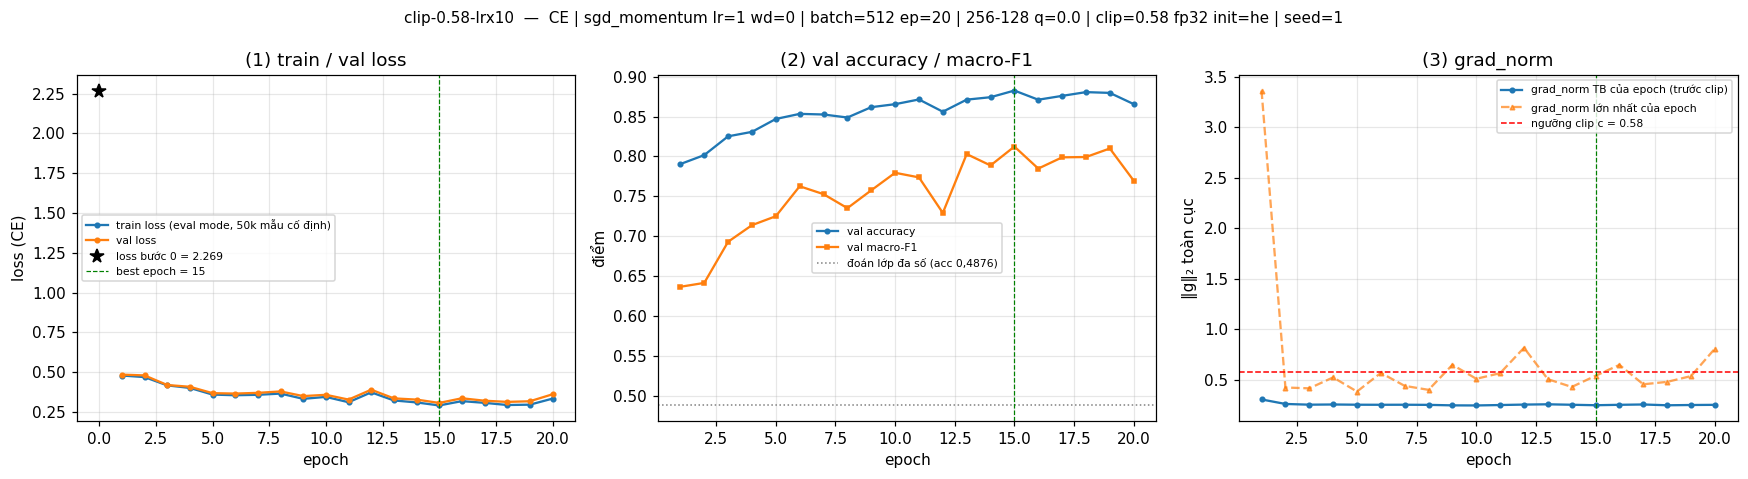

[clip-none-lrx30] ep  1  train 1.2265  val 1.2293  acc 0.4876  F1 0.0936  |g| 0.465  1.4s
[clip-none-lrx30] ep  2  train 1.2072  val 1.2092  acc 0.4876  F1 0.0936  |g| 0.093  1.3s
[clip-none-lrx30] ep  3  train 1.2118  val 1.2130  acc 0.4876  F1 0.0936  |g| 0.095  1.5s
[clip-none-lrx30] ep  4  train 1.2261  val 1.2281  acc 0.4876  F1 0.0936  |g| 0.078  1.2s
[clip-none-lrx30] ep  5  train 1.2208  val 1.2230  acc 0.4876  F1 0.0936  |g| 0.072  1.2s
[clip-none-lrx30] ep  6  train 1.2103  val 1.2118  acc 0.4876  F1 0.0936  |g| 0.085  1.3s
[clip-none-lrx30] ep  7  train 1.2063  val 1.2081  acc 0.4876  F1 0.0936  |g| 0.086  1.2s
[clip-none-lrx30] ep  8  train 1.2058  val 1.2078  acc 0.4876  F1 0.0936  |g| 0.074  1.3s
[clip-none-lrx30] ep  9  train 1.2320  val 1.2335  acc 0.3646  F1 0.0763  |g| 0.090  1.2s
[clip-none-lrx30] ep 10  train 1.2145  val 1.2160  acc 0.4876  F1 0.0936  |g| 0.077  1.3s
[clip-none-lrx30] ep 11  train 1.2313  val 1.2324  acc 0.3646  F1 0.0763  |g| 0.085  1.3s
[clip-none

,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,0.1000,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2641,172.8032,False,0.0021,Không
clip-0.58,0.1000,2.2691,18,0.2280,0.2107,0.2338,0.9090,0.8591,1.2300,172.8032,False,0.0028,Không
clip-none-lrx10,1.0000,2.2691,15,0.3582,0.3954,0.4108,0.8578,0.7670,1.2629,172.8032,False,-0.0893,Có
clip-0.58-lrx10,1.0000,2.2691,15,0.3070,0.3341,0.3613,0.8827,0.8124,1.2536,172.8032,False,-0.0438,Có
clip-none-lrx30,3.0000,2.2691,19,1.2072,1.2082,1.2104,0.4876,0.0936,1.2771,172.8032,False,-0.7626,Có
clip-0.58-lrx30,3.0000,2.2691,1,0.9447,1.0110,1.0167,0.4870,0.1504,1.2494,172.8032,False,-0.7058,Có


clip-0.58        tỉ lệ bước bị clip theo epoch: [0.38, 0.48, 0.53, 0.56, 0.55, 0.6, 0.57, 0.55, 0.55, 0.58] ...
clip-none-lrx10  tỉ lệ bước bị clip theo epoch: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] ...
clip-0.58-lrx10  tỉ lệ bước bị clip theo epoch: [0.02, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] ...
clip-none-lrx30  tỉ lệ bước bị clip theo epoch: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] ...
clip-0.58-lrx30  tỉ lệ bước bị clip theo epoch: [0.06, 0.02, 0.01, 0.0, 0.01, 0.01, 0.0, 0.0, 0.0, 0.0] ...


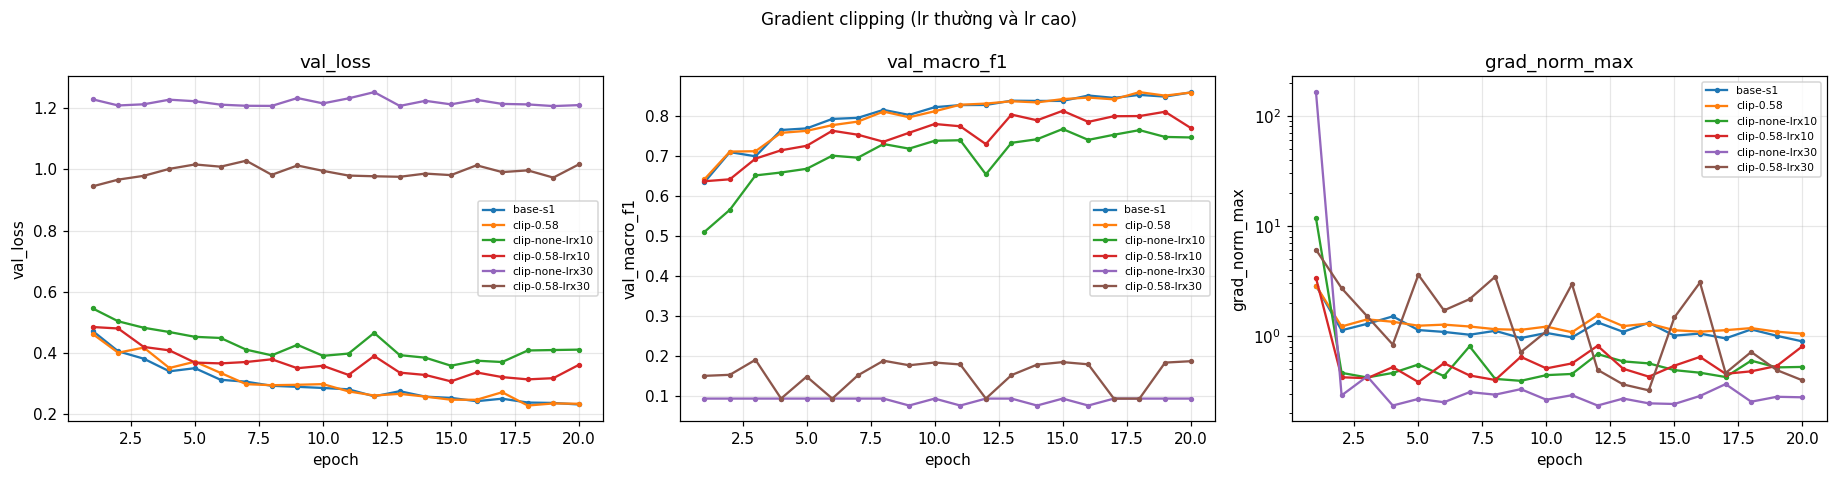

In [12]:
gn = np.array(base_runs[0]["history"]["grad_norm"])
gmax = np.array(base_runs[0]["history"]["grad_norm_max"])
C = float(f"{np.median(gn):.2g}")
print("base-s1 grad_norm TB theo epoch:", gn.round(3))
print("base-s1 grad_norm max theo epoch:", gmax.round(3))
print("chọn c =", C)
clip_runs = [R({**BASE, "exp_id": f"clip-{C:g}", "group": "clipping", "clip_norm": C, "description": f"clip c={C:g} (trung vị grad_norm baseline), lr baseline"})]
for k in (10, 30):
    clip_runs.append(R({**BASE, "exp_id": f"clip-none-lrx{k}", "group": "clipping", "lr": k * BASE_LR,
                        "description": f"lr x{k}, KHÔNG clip (phản chứng)"}, show=False))
    clip_runs.append(R({**BASE, "exp_id": f"clip-{C:g}-lrx{k}", "group": "clipping", "lr": k * BASE_LR, "clip_norm": C,
                        "description": f"lr x{k}, clip c={C:g}"}, show=(k == 10)))
df_clip = table([base_runs[0]] + clip_runs, BASE_F1, NOISE)
for r in clip_runs:
    print(f"{r['cfg']['exp_id']:16s} tỉ lệ bước bị clip theo epoch:", np.round(r["history"]["clip_frac"], 2).tolist()[:10], "...")
plot_compare([base_runs[0]] + clip_runs, ["val_loss", "val_macro_f1", "grad_norm_max"], f"{OUT_DIR}/figures/compare_clipping.png", "Gradient clipping (lr thường và lr cao)")
display(Image(f"{OUT_DIR}/figures/compare_clipping.png", width=950))

**Đối chiếu (clipping):** khớp ở lr thường và lr ×10; ở lr ×30 clipping không cứu được.
- Chọn c = **0,58** = trung vị grad_norm TB theo epoch của `base-s1` (0,53–0,60, gai lớn nhất 2,87 ở epoch 1). Ở lr baseline, clipping kích hoạt ở **38–60%** số bước (`clip_frac`) nhưng F1 = **0,8591** vs 0,8562 ± 0,0019 → +0,003, **trong nhiễu**: vì gradient chỉ lớn hơn c chút ít, cắt bớt tương đương giảm nhẹ lr ở các bước đó.
- Phản chứng lr ×10 (lr = 1): không clip có gai grad_norm **11,7** ở epoch 1 và F1 dao động (0,51 → 0,77, có lúc tụt 0,65), best **0,7670**; có clip: gai chỉ 3,4, F1 **0,8124** (+0,045, vượt 2σ). Clipping chặn bước cập nhật ‖Δw‖ ≤ lr·c ở các bước gradient bùng nổ đầu huấn luyện, nên mô hình không bị đẩy vào vùng tồi.
- lr ×30 (lr = 3): không clip có một gai **163,5** ở epoch 1, sau đó grad_norm ≈ 0,1–0,3 và F1 kẹt ở **0,0936** = đoán luôn lớp đa số (không NaN, nhưng nơ-ron ReLU chết sau bước nhảy lớn → mạng chỉ còn học bias). Có clip vẫn hỏng (F1 0,15): clipping chỉ chặn *độ dài mỗi bước*, còn lr = 3 với momentum 0,9 thì bước hiệu dụng vẫn quá lớn → clipping không thay thế được việc giảm lr.
- Cờ `diverged` = False ở cả 4 lần chạy lr cao: hỏng theo kiểu "kẹt" chứ không phải NaN — vì vậy phải nhìn grad_norm và F1, không chỉ chờ NaN.

### Chủ đề 6 — Mixed precision (`amp-*`)
FP16: `autocast(float16)` + `GradScaler` (unscale trước khi đo/clip gradient). BF16: `autocast(bfloat16)`, không GradScaler. Tham số vẫn FP32.

**Dự đoán trước:** độ chính xác (F1) gần như không đổi so với FP32 (trong nhiễu). Với mạng rất nhỏ (48k tham số) và batch 512, thời gian bị chi phối bởi chi phí gọi kernel
và vòng lặp Python, nên FP16 **có thể không nhanh hơn** (thậm chí chậm hơn vì thêm bước ép kiểu và GradScaler); bộ nhớ cực đại cũng gần như không đổi vì dữ liệu đã nằm trên GPU ở FP32.
BF16 trên T4 (không có phần cứng BF16) sẽ chậm hơn. Với M-wide, FP16 có nhiều cơ hội có lợi hơn.

GPU hỗ trợ BF16: True
[amp-fp16] ep  1  train 0.4786  val 0.4800  acc 0.7907  F1 0.6333  |g| 0.530  1.7s
[amp-fp16] ep  2  train 0.3975  val 0.4050  acc 0.8270  F1 0.7099  |g| 0.567  1.9s
[amp-fp16] ep  3  train 0.3902  val 0.3982  acc 0.8386  F1 0.6960  |g| 0.594  1.9s
[amp-fp16] ep  4  train 0.3455  val 0.3528  acc 0.8530  F1 0.7564  |g| 0.598  1.6s
[amp-fp16] ep  5  train 0.3476  val 0.3601  acc 0.8493  F1 0.7651  |g| 0.587  1.6s
[amp-fp16] ep  6  train 0.3056  val 0.3138  acc 0.8712  F1 0.7892  |g| 0.599  1.6s
[amp-fp16] ep  7  train 0.2985  val 0.3077  acc 0.8724  F1 0.7870  |g| 0.582  1.6s
[amp-fp16] ep  8  train 0.2813  val 0.2925  acc 0.8784  F1 0.8179  |g| 0.576  1.6s
[amp-fp16] ep  9  train 0.2760  val 0.2909  acc 0.8834  F1 0.8079  |g| 0.579  1.6s
[amp-fp16] ep 10  train 0.2654  val 0.2843  acc 0.8855  F1 0.8225  |g| 0.576  1.8s
[amp-fp16] ep 11  train 0.2606  val 0.2766  acc 0.8889  F1 0.8271  |g| 0.582  2.0s
[amp-fp16] ep 12  train 0.2477  val 0.2681  acc 0.8953  F1 0.8279

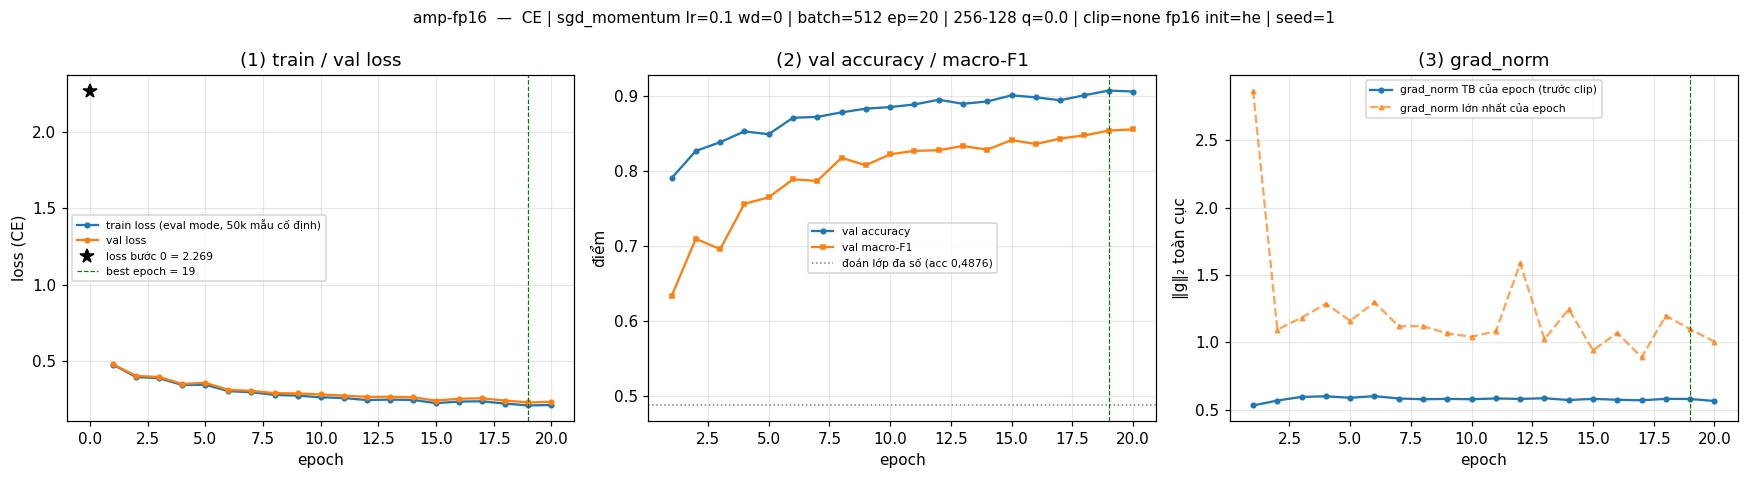

[amp-bf16] ep  1  train 0.4809  val 0.4823  acc 0.7888  F1 0.6287  |g| 0.533  1.4s
[amp-bf16] ep  2  train 0.3970  val 0.4049  acc 0.8272  F1 0.7112  |g| 0.561  1.4s
[amp-bf16] ep  3  train 0.3735  val 0.3812  acc 0.8437  F1 0.7154  |g| 0.593  1.4s
[amp-bf16] ep  4  train 0.3407  val 0.3487  acc 0.8541  F1 0.7619  |g| 0.588  1.4s
[amp-bf16] ep  5  train 0.3338  val 0.3458  acc 0.8552  F1 0.7699  |g| 0.588  1.4s
[amp-bf16] ep  6  train 0.2984  val 0.3058  acc 0.8732  F1 0.7927  |g| 0.593  1.6s
[amp-bf16] ep  7  train 0.2946  val 0.3066  acc 0.8723  F1 0.7928  |g| 0.581  1.7s
[amp-bf16] ep  8  train 0.2853  val 0.2973  acc 0.8778  F1 0.8188  |g| 0.578  1.6s
[amp-bf16] ep  9  train 0.2817  val 0.2969  acc 0.8794  F1 0.8023  |g| 0.581  1.4s
[amp-bf16] ep 10  train 0.2595  val 0.2772  acc 0.8873  F1 0.8236  |g| 0.577  1.4s
[amp-bf16] ep 11  train 0.2426  val 0.2584  acc 0.8957  F1 0.8339  |g| 0.575  1.4s
[amp-bf16] ep 12  train 0.2375  val 0.2549  acc 0.8964  F1 0.8313  |g| 0.576  1.4s
[amp

,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,0.1000,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2641,172.8032,False,0.0021,Không
amp-fp16,0.1000,2.2691,19,0.2318,0.2150,0.2359,0.9075,0.8541,1.6952,172.8022,False,-0.0021,Không
amp-bf16,0.1000,2.2691,20,0.2280,0.2068,0.2280,0.9093,0.8515,1.4615,172.8013,False,-0.0047,Có
hp-wide,0.1000,1.9182,19,0.2021,0.1758,0.2043,0.9209,0.8725,1.2802,190.1011,False,0.0162,Có
amp-wide-fp16,0.1000,1.9182,19,0.1999,0.1777,0.2040,0.9215,0.8821,1.6868,190.1001,False,0.0259,Có


amp-fp16       số bước bị GradScaler bỏ qua (tổng): 4
amp-bf16       số bước bị GradScaler bỏ qua (tổng): 0
amp-wide-fp16  số bước bị GradScaler bỏ qua (tổng): 3


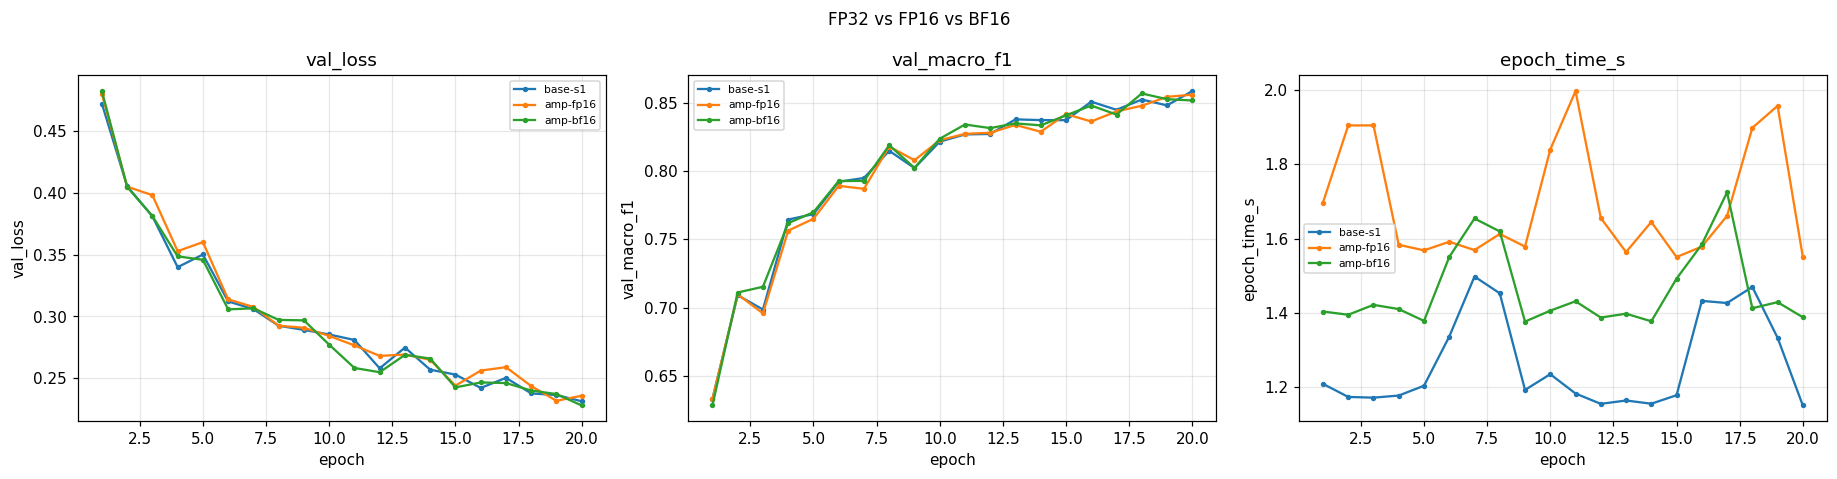

In [13]:
print("GPU hỗ trợ BF16:", torch.cuda.is_bf16_supported() if device == "cuda" else "không có GPU")
amp_runs = [R({**BASE, "exp_id": "amp-fp16", "group": "amp", "precision": "fp16", "description": "FP16 autocast + GradScaler"})]
try:
    amp_runs.append(R({**BASE, "exp_id": "amp-bf16", "group": "amp", "precision": "bf16", "description": "BF16 autocast, không GradScaler"}, show=False))
except Exception as e:
    print("BF16 không chạy được trên máy này:", repr(e))
amp_runs.append(R({**BASE, "exp_id": "amp-wide-fp16", "group": "amp", "precision": "fp16", "hidden": (512, 256),
                   "description": "M-wide + FP16 (so với hp-wide FP32)"}, show=False))
hp_wide = [r for r in hp_runs if r["cfg"]["exp_id"] == "hp-wide"][0]
df_amp = table([base_runs[0]] + amp_runs[:-1] + [hp_wide, amp_runs[-1]], BASE_F1, NOISE)
for r in amp_runs:
    print(f"{r['cfg']['exp_id']:14s} số bước bị GradScaler bỏ qua (tổng):", int(np.sum(r["history"]["skipped_steps"])))
plot_compare([base_runs[0]] + amp_runs[:-1], ["val_loss", "val_macro_f1", "epoch_time_s"], f"{OUT_DIR}/figures/compare_amp.png", "FP32 vs FP16 vs BF16")
display(Image(f"{OUT_DIR}/figures/compare_amp.png", width=950))

**Đối chiếu (amp):** khớp dự đoán "không nhanh hơn".
- Thời gian/epoch (Tesla T4): FP32 **1,26 s**, FP16 **1,70 s** (chậm hơn 35%), BF16 **1,46 s** (chậm hơn 16%). Bộ nhớ cực đại như nhau: **172,8 MB** (toàn bộ dữ liệu FP32 đã nằm trên GPU chiếm phần lớn; activations của MLP 48k tham số rất nhỏ).
- Độ chính xác: FP16 **0,8541** (−0,002, trong nhiễu), BF16 **0,8515** (−0,005, vừa vượt 2σ, 1 seed → chưa kết luận được). GradScaler bỏ qua 4 bước (FP16) do tràn số và tự giảm hệ số s — đúng cơ chế của loss scaling.
- M-wide: FP32 (`hp-wide`) 1,28 s/epoch, F1 0,8725; FP16 (`amp-wide-fp16`) 1,69 s/epoch, F1 0,8821. Vẫn chậm hơn; chênh F1 +0,010 là 1 seed, khó tách khỏi nhiễu số học/khác thứ tự phép tính.
- Cơ chế: với mạng nhỏ, mỗi bước chỉ vài phép nhân ma trận nhỏ → thời gian bị chi phối bởi chi phí gọi kernel, ép kiểu (autocast) và vòng lặp Python; FP16 còn thêm `unscale_`/kiểm tra inf của GradScaler. T4 có Tensor Core FP16 nhưng ma trận quá nhỏ để được lợi. `torch.cuda.is_bf16_supported()` trả về True nhưng T4 (sm_75) không có phần cứng BF16 nên BF16 không thể nhanh hơn.
- FP16 cần nhân loss với s vì khoảng biểu diễn hẹp (≈ 6e-5 … 65 504) → gradient nhỏ bị underflow về 0; BF16 có cùng 8 bit mũ như FP32 (≈ 1e-38 … 3e38) nên không cần loss scaling, đổi lại độ chính xác phần định trị thấp hơn.

### Chủ đề 7 — Khởi tạo tham số (`init-*`)
`xavier` ở đây là `xavier_normal_` (Var = 2/(n_vào+n_ra)); `he` là `kaiming_normal_` (Var = 2/n_vào); `default` là khởi tạo mặc định của `nn.Linear`
(kaiming_uniform với a = √5, tức U(±1/√n_vào), Var = 1/(3·n_vào)) và bias mặc định ≠ 0.

**Dự đoán trước:**
- `zeros`: mọi nơ-ron trong một lớp ẩn có cùng đầu ra 0, ReLU(0) = 0 và đạo hàm tại 0 bằng 0 (theo quy ước PyTorch) → gradient của W1, W2 bằng 0, chỉ bias lớp cuối học được.
  Mạng chỉ học được prior của lớp (đoán lớp đa số) → acc ≈ 0,4876, macro-F1 ≈ 0,094. Loss bước 0 = ln 7 chính xác.
- `normal` (std 0,01): kích hoạt co lại ~0,01·√n mỗi lớp → tín hiệu và gradient rất nhỏ ở bước 0, học chậm lúc đầu nhưng với 3 lớp vẫn thoát được.
- `xavier` và `default`: phương sai nhỏ hơn He (với ReLU, kích hoạt giảm dần qua các lớp), nhưng mạng chỉ 3 lớp nên khác biệt F1 so với He có thể nằm trong nhiễu.
  Để thấy rõ hiện tượng như biểu đồ "30 lớp ReLU" của slide, ta đo thêm std kích hoạt của một mạng 30 lớp (không huấn luyện).

[init-zeros] ep  1  train 1.2035  val 1.2053  acc 0.4876  F1 0.0936  |g| 0.040  1.2s
[init-zeros] ep  2  train 1.2035  val 1.2053  acc 0.4876  F1 0.0936  |g| 0.034  1.2s
[init-zeros] ep  3  train 1.2038  val 1.2056  acc 0.4876  F1 0.0936  |g| 0.034  1.3s
[init-zeros] ep  4  train 1.2035  val 1.2054  acc 0.4876  F1 0.0936  |g| 0.032  1.2s
[init-zeros] ep  5  train 1.2038  val 1.2055  acc 0.4876  F1 0.0936  |g| 0.033  1.2s
[init-zeros] ep  6  train 1.2035  val 1.2053  acc 0.4876  F1 0.0936  |g| 0.035  1.2s
[init-zeros] ep  7  train 1.2039  val 1.2056  acc 0.4876  F1 0.0936  |g| 0.033  1.2s
[init-zeros] ep  8  train 1.2040  val 1.2056  acc 0.4876  F1 0.0936  |g| 0.033  1.2s
[init-zeros] ep  9  train 1.2037  val 1.2054  acc 0.4876  F1 0.0936  |g| 0.033  1.4s
[init-zeros] ep 10  train 1.2037  val 1.2055  acc 0.4876  F1 0.0936  |g| 0.034  1.4s
[init-zeros] ep 11  train 1.2035  val 1.2053  acc 0.4876  F1 0.0936  |g| 0.034  1.4s
[init-zeros] ep 12  train 1.2035  val 1.2054  acc 0.4876  F1 0.09

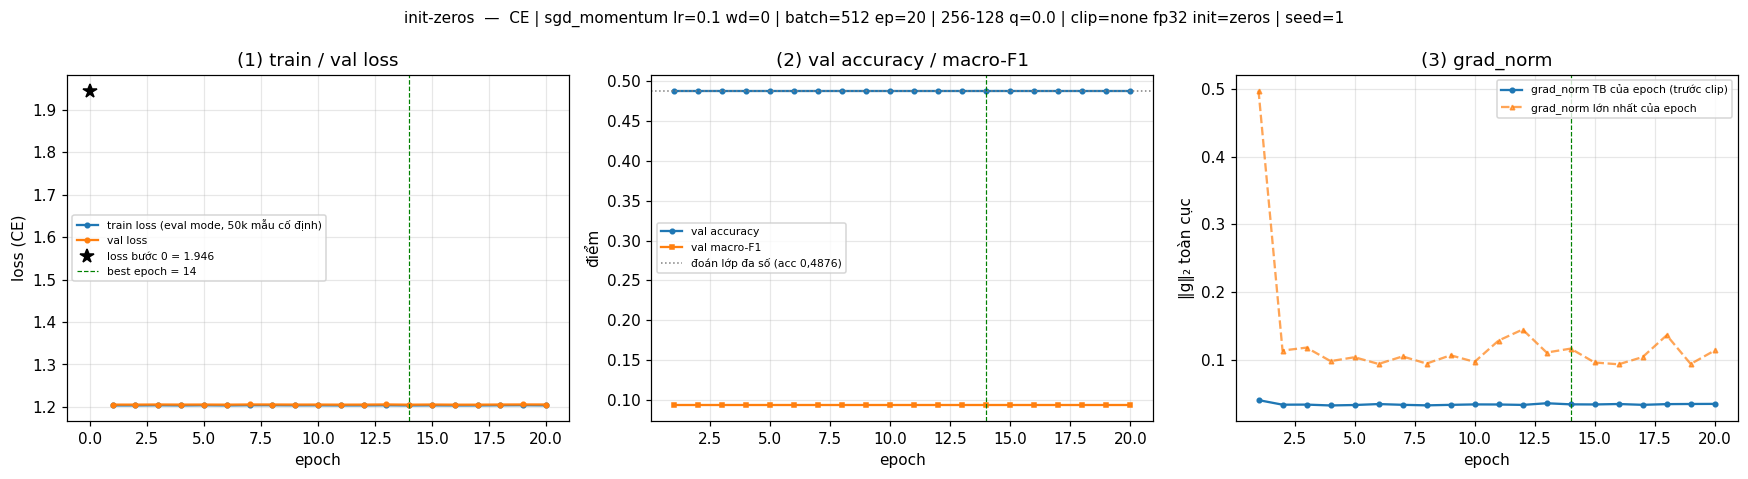

[init-normal] ep  1  train 0.5652  val 0.5669  acc 0.7557  F1 0.4803  |g| 0.304  1.3s
[init-normal] ep  2  train 0.4886  val 0.4926  acc 0.7834  F1 0.6459  |g| 0.543  1.2s
[init-normal] ep  3  train 0.4683  val 0.4730  acc 0.8032  F1 0.6209  |g| 0.617  1.2s
[init-normal] ep  4  train 0.4015  val 0.4046  acc 0.8283  F1 0.6997  |g| 0.641  1.1s
[init-normal] ep  5  train 0.3972  val 0.4029  acc 0.8310  F1 0.6989  |g| 0.640  1.2s
[init-normal] ep  6  train 0.3451  val 0.3491  acc 0.8539  F1 0.7332  |g| 0.634  1.2s
[init-normal] ep  7  train 0.3219  val 0.3307  acc 0.8634  F1 0.7355  |g| 0.637  1.2s
[init-normal] ep  8  train 0.3069  val 0.3150  acc 0.8703  F1 0.7984  |g| 0.632  1.2s
[init-normal] ep  9  train 0.3085  val 0.3190  acc 0.8684  F1 0.7768  |g| 0.622  1.2s
[init-normal] ep 10  train 0.2874  val 0.3002  acc 0.8767  F1 0.8058  |g| 0.615  1.4s
[init-normal] ep 11  train 0.2627  val 0.2766  acc 0.8872  F1 0.8008  |g| 0.618  1.4s
[init-normal] ep 12  train 0.3076  val 0.3206  acc 0.8

,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
base-s1,0.1000,2.2691,20,0.2314,0.2091,0.2314,0.9085,0.8584,1.2641,172.8032,False,0.0021,Không
init-zeros,0.1000,1.9459,14,1.2052,1.2036,1.2056,0.4876,0.0936,1.2505,172.8032,False,-0.7626,Có
init-normal,0.1000,1.9460,19,0.2400,0.2415,0.2580,0.9028,0.8485,1.2273,172.8032,False,-0.0077,Có
init-xavier,0.1000,2.0222,18,0.2300,0.2138,0.2345,0.9094,0.8585,1.2192,172.8032,False,0.0023,Không
init-default,0.1000,1.9830,20,0.2406,0.2203,0.2406,0.9045,0.8510,1.2691,172.8032,False,-0.0052,Có


độ lệch chuẩn kích hoạt ở bước 0 (sau ReLU1, ReLU2, logit) trên 4096 mẫu val:
  he       [0.39012, 0.36613, 0.57728]   loss bước 0 = 2.2691
  zeros    [0.0, 0.0, 0.0]   loss bước 0 = 1.9459
  normal   [0.02027, 0.00215, 0.00027]   loss bước 0 = 1.9460
  xavier   [0.16282, 0.12477, 0.19156]   loss bước 0 = 2.0222
  default  [0.16028, 0.06776, 0.05851]   loss bước 0 = 1.9830


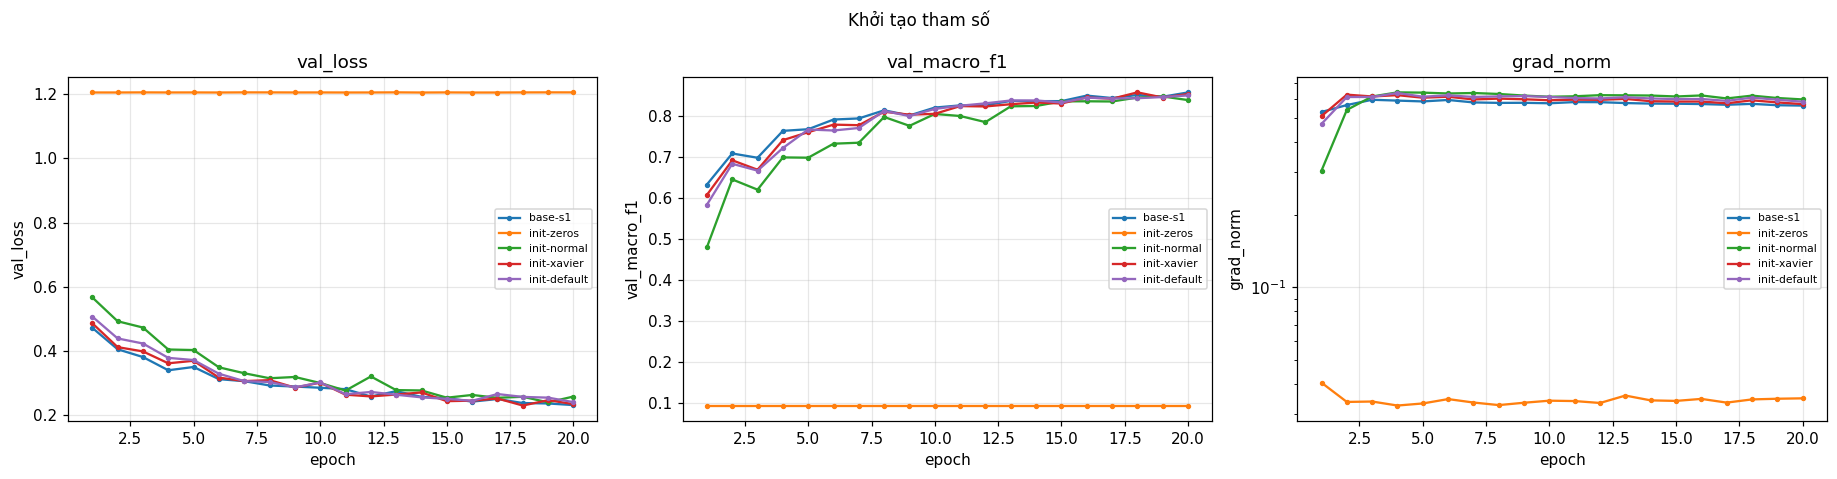

In [14]:
init_runs = [R({**BASE, "exp_id": f"init-{name}", "group": "init", "init": name, "description": f"khởi tạo {name}, bias=0" if name != "default" else "khởi tạo mặc định nn.Linear"},
               show=(name == "zeros")) for name in ("zeros", "normal", "xavier", "default")]
df_init = table([base_runs[0]] + init_runs, BASE_F1, NOISE)
print("độ lệch chuẩn kích hoạt ở bước 0 (sau ReLU1, ReLU2, logit) trên 4096 mẫu val:")
for r in [base_runs[0]] + init_runs:
    print(f"  {r['cfg']['init']:8s}", np.round(r["summary"]["act_std_step0"], 5).tolist(), f"  loss bước 0 = {r['summary']['step0_loss']:.4f}")
plot_compare([base_runs[0]] + init_runs, ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_init.png", "Khởi tạo tham số")
display(Image(f"{OUT_DIR}/figures/compare_init.png", width=950))

normal   std lớp 1, 10, 20, 30: ['2.02e-02', '4.91e-11', '2.01e-20', '0.00e+00']
xavier   std lớp 1, 10, 20, 30: ['1.62e-01', '5.74e-03', '2.14e-04', '6.94e-06']
he       std lớp 1, 10, 20, 30: ['3.89e-01', '3.11e-01', '3.71e-01', '3.85e-01']
default  std lớp 1, 10, 20, 30: ['1.67e-01', '2.32e-02', '2.15e-02', '2.35e-02']


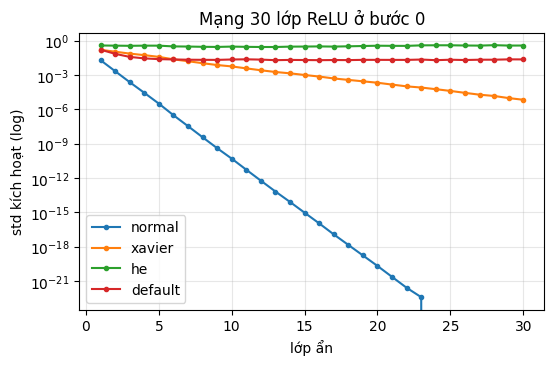

In [15]:
# Minh hoạ "30 lớp ReLU" (không huấn luyện, không phải một dòng thí nghiệm): std kích hoạt qua 30 lớp ẩn 256 nơ-ron
import torch.nn as nn
from model import init_weights
xb = data["X_val"][:4096]
plt.figure(figsize=(6, 3.6))
for name in ("normal", "xavier", "he", "default"):
    set_seed(0)
    layers = []
    n_in = 54
    for _ in range(30):
        layers += [nn.Linear(n_in, 256), nn.ReLU()]; n_in = 256
    deep = nn.Sequential(*layers).to(device)
    init_weights(deep, name)
    stds, h = [], xb
    with torch.no_grad():
        for layer in deep:
            h = layer(h)
            if isinstance(layer, nn.ReLU):
                stds.append(h.std().item())
    plt.semilogy(range(1, 31), stds, "o-", ms=3, label=name)
    print(f"{name:8s} std lớp 1, 10, 20, 30:", [f"{stds[i]:.2e}" for i in (0, 9, 19, 29)])
plt.xlabel("lớp ẩn"); plt.ylabel("std kích hoạt (log)"); plt.title("Mạng 30 lớp ReLU ở bước 0"); plt.legend(); plt.grid(alpha=.3)
plt.savefig(f"{OUT_DIR}/figures/compare_init_deep30.png", dpi=110, bbox_inches="tight"); plt.show()

**Đối chiếu (init):** khớp dự đoán; trên mạng 3 lớp khác biệt nhỏ, trên mạng 30 lớp khác biệt rất rõ.
- `init-zeros`: std kích hoạt bước 0 = [0, 0, 0], loss bước 0 = **1,9459 = ln 7** chính xác; sau 20 epoch acc **0,4876**, macro-F1 **0,0936** = đúng chiến lược đoán lớp đa số; grad_norm TB chỉ 0,034. Cơ chế: mọi nơ-ron cùng lớp nhận cùng đầu vào 0 → cùng đầu ra, ReLU'(0) = 0 nên gradient của W1, W2, b1, b2 bằng 0 và h2 = 0 nên gradient của W3 cũng bằng 0; chỉ bias lớp cuối học được → mạng chỉ học prior của lớp (đối xứng không bao giờ bị phá vỡ).
- `init-normal` (std 0,01): std kích hoạt [0,020, 0,0022, 0,0003] — co lại ~10 lần mỗi lớp, loss bước 0 = 1,9460; vẫn học được nhưng F1 **0,8485** (−0,008, vượt 2σ).
- `init-xavier` (xavier_normal_, Var = 2/(n_vào+n_ra)): std [0,163, 0,125, 0,192], F1 **0,8585** (+0,002, trong nhiễu). `init-default` (U(±1/√n_vào), bias ≠ 0): std [0,160, 0,068, 0,059], F1 **0,8510** (−0,005, vừa vượt 2σ). He: std [0,390, 0,366, 0,577] — giữ gần như không đổi qua các lớp.
- Mạng 30 lớp ReLU (`compare_init_deep30.png`): std ở lớp 30 — He **3,9e-1** (ổn định), default 2,4e-2, Xavier **6,9e-6**, normal **0** (tắt hẳn). He bù hệ số 1/2 do ReLU cắt nửa phân phối (Var = 2/n_vào), Xavier thì không → tín hiệu giảm ~√2 mỗi lớp. Với 3 lớp hiệu ứng này nhỏ (Xavier ≈ He trong nhiễu); nó chỉ quan trọng với mạng sâu.

### Kết hợp — cấu hình cuối cùng (`final-*`), chọn **chỉ bằng val**
Lấy bộ tối ưu + lr tốt nhất theo val ở chủ đề 2 (nếu nó tốt hơn SGD+momentum), kết hợp với những yếu tố có ích theo val ở chủ đề 3 (M-wide, 40 epoch).
Hai ứng viên: (A) như trên; (B) như A + lịch lr cosine. Chọn ứng viên có val macro-F1 cao hơn, rồi chạy thêm 2 seed để đo nhiễu.

**Dự đoán trước:** cấu hình cuối sẽ vượt baseline rõ rệt (> 2σ), vì baseline chưa hội tụ ở 20 epoch và năng lực của M-base còn hạn chế; cosine giúp giảm dao động ở cuối nên có thể nhỉnh hơn.

bộ tối ưu tốt nhất theo val: opt-adamw-lr0.003 adamw 0.003 F1=0.8757
[final-A-s1] ep  1  train 0.4035  val 0.4050  acc 0.8291  F1 0.7054  |g| 0.632  1.6s
[final-A-s1] ep  2  train 0.3261  val 0.3350  acc 0.8612  F1 0.7860  |g| 0.585  1.6s
[final-A-s1] ep  3  train 0.2971  val 0.3079  acc 0.8720  F1 0.7944  |g| 0.570  1.5s
[final-A-s1] ep  4  train 0.2693  val 0.2825  acc 0.8844  F1 0.8289  |g| 0.550  1.4s
[final-A-s1] ep  5  train 0.2496  val 0.2649  acc 0.8925  F1 0.8361  |g| 0.546  1.4s
[final-A-s1] ep  6  train 0.2364  val 0.2524  acc 0.8975  F1 0.8493  |g| 0.559  1.4s
[final-A-s1] ep  7  train 0.2168  val 0.2368  acc 0.9036  F1 0.8477  |g| 0.549  1.5s
[final-A-s1] ep  8  train 0.2188  val 0.2378  acc 0.9038  F1 0.8612  |g| 0.522  1.4s
[final-A-s1] ep  9  train 0.1913  val 0.2155  acc 0.9130  F1 0.8652  |g| 0.535  1.4s
[final-A-s1] ep 10  train 0.1909  val 0.2144  acc 0.9137  F1 0.8689  |g| 0.535  1.6s
[final-A-s1] ep 11  train 0.1875  val 0.2128  acc 0.9132  F1 0.8674  |g| 0.509  1

,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
final-A-s1,0.0030,1.9182,32,0.1642,0.1356,0.1728,0.9345,0.9018,1.4552,202.0322,False,0.0456,Có
final-B-s1,0.0030,1.9182,39,0.1212,0.0755,0.1212,0.9536,0.9277,1.4520,202.0322,False,0.0715,Có


cấu hình cuối cùng (theo val): final-B-s1
[final-B-s2] ep  1  train 0.4054  val 0.4110  acc 0.8274  F1 0.7171  |g| 0.693  1.3s
[final-B-s2] ep  2  train 0.3501  val 0.3572  acc 0.8538  F1 0.7728  |g| 0.652  1.4s
[final-B-s2] ep  3  train 0.3073  val 0.3180  acc 0.8684  F1 0.7905  |g| 0.627  1.6s
[final-B-s2] ep  4  train 0.2671  val 0.2802  acc 0.8830  F1 0.8199  |g| 0.621  1.7s
[final-B-s2] ep  5  train 0.2441  val 0.2578  acc 0.8955  F1 0.8451  |g| 0.602  1.5s
[final-B-s2] ep  6  train 0.2341  val 0.2490  acc 0.9007  F1 0.8412  |g| 0.626  1.4s
[final-B-s2] ep  7  train 0.2203  val 0.2391  acc 0.9021  F1 0.8436  |g| 0.600  1.5s
[final-B-s2] ep  8  train 0.2018  val 0.2213  acc 0.9099  F1 0.8640  |g| 0.595  1.4s
[final-B-s2] ep  9  train 0.2052  val 0.2257  acc 0.9100  F1 0.8585  |g| 0.607  1.3s
[final-B-s2] ep 10  train 0.1971  val 0.2197  acc 0.9113  F1 0.8659  |g| 0.599  1.5s
[final-B-s2] ep 11  train 0.1940  val 0.2158  acc 0.9120  F1 0.8733  |g| 0.585  1.4s
[final-B-s2] ep 12  tra

,lr,step0,best_ep,best_val_loss,train_loss,val_loss,val_acc,val_F1,s_per_ep,mem_MB,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,,
final-B-s1,0.0030,1.9182,39,0.1212,0.0755,0.1212,0.9536,0.9277,1.4520,202.0322,False,0.0715,Có
final-B-s2,0.0030,2.6520,40,0.1264,0.0818,0.1264,0.9516,0.9215,1.4422,202.0322,False,0.0653,Có
final-B-s3,0.0030,2.7882,39,0.1243,0.0783,0.1243,0.9526,0.9265,1.4252,202.0322,False,0.0702,Có


final val macro-F1: 0.9252 ± 0.0033 (3 seed)   vs baseline 0.8562 ± 0.0019


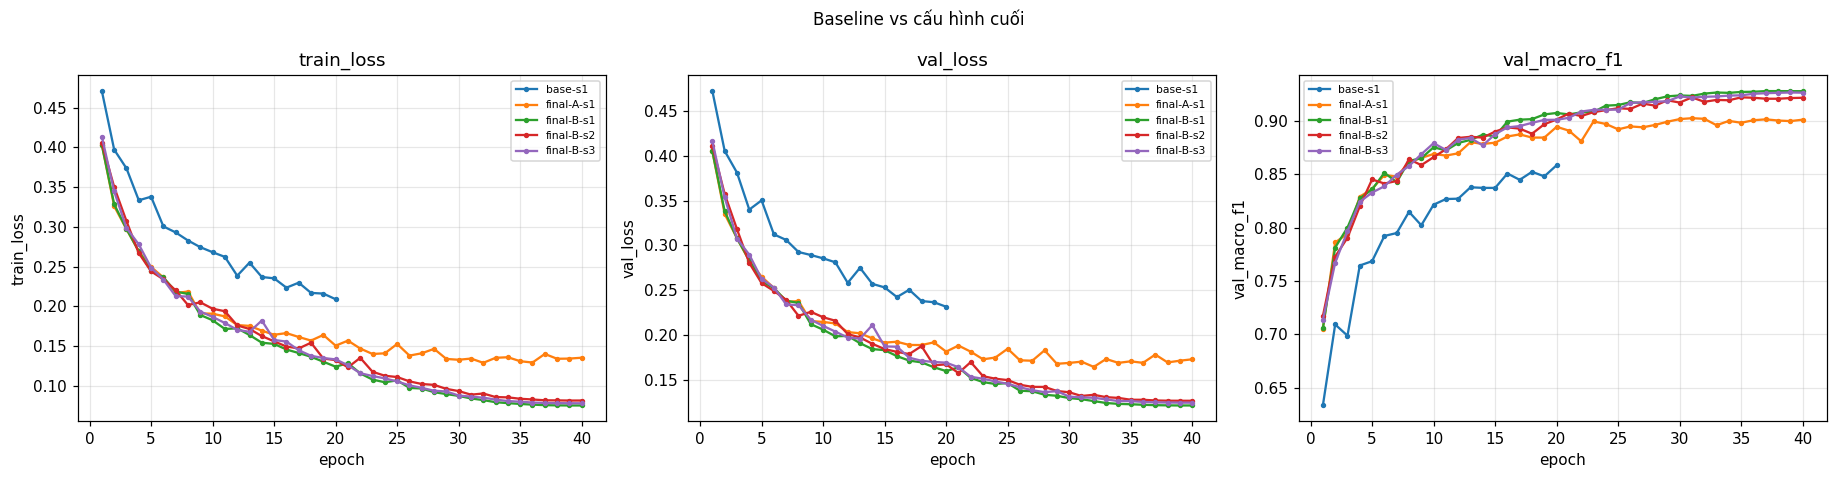

In [16]:
best_overall = max(best_opt.values(), key=lambda r: r["summary"]["val_macro_f1"])
oc = best_overall["cfg"]
print("bộ tối ưu tốt nhất theo val:", oc["exp_id"], oc["optimizer"], oc["lr"], f"F1={best_overall['summary']['val_macro_f1']:.4f}")
FINAL_BASE = {**BASE, "optimizer": oc["optimizer"], "lr": oc["lr"], "weight_decay": oc["weight_decay"],
              "hidden": (512, 256), "epochs": 40, "group": "final"}
cand = [
    R({**FINAL_BASE, "exp_id": "final-A-s1", "description": f"{oc['optimizer']} lr={oc['lr']:g} + M-wide + 40 epoch"}, keep_state=True, show=False),
    R({**FINAL_BASE, "exp_id": "final-B-s1", "scheduler": "cosine", "description": f"{oc['optimizer']} lr={oc['lr']:g} + M-wide + 40 epoch + cosine"}, keep_state=True, show=False),
]
table(cand, BASE_F1, NOISE)
chosen = max(cand, key=lambda r: r["summary"]["val_macro_f1"])
tag = chosen["cfg"]["exp_id"].split("-")[1]
print("cấu hình cuối cùng (theo val):", chosen["cfg"]["exp_id"])
final_runs = [chosen] + [R({**chosen["cfg"], "seed": s, "exp_id": f"final-{tag}-s{s}", "description": chosen["cfg"]["description"] + f", seed {s}"}, show=False)
                         for s in (2, 3)]
df_final = table(final_runs, BASE_F1, NOISE)
ff1 = np.array([r["summary"]["val_macro_f1"] for r in final_runs])
print(f"final val macro-F1: {ff1.mean():.4f} ± {ff1.std(ddof=1):.4f} (3 seed)   vs baseline {BASE_F1:.4f} ± {BASE_SD:.4f}")
plot_compare([base_runs[0]] + cand + final_runs[1:], ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_final.png", "Baseline vs cấu hình cuối")
display(Image(f"{OUT_DIR}/figures/compare_final.png", width=950))

**Đối chiếu (final):** khớp dự đoán.
- Bộ tối ưu tốt nhất theo val là AdamW lr 3e-3 (wd 0,01) → hai ứng viên M-wide + 40 epoch: (A) không lịch lr → val F1 **0,9018**; (B) thêm cosine → **0,9277**. Chọn **B** chỉ bằng val. Cấu hình cuối đổi nhiều yếu tố cùng lúc (optimizer, lr, độ rộng, số epoch, lịch lr) — đây là bước *kết hợp*, mỗi yếu tố đã được thử riêng ở trên.
- 3 seed của B: 0,9277 / 0,9215 / 0,9265 → **0,9252 ± 0,0033**, so với baseline 0,8562 ± 0,0019: +0,069, gấp ~19 lần ngưỡng 2σ của baseline → khác biệt chắc chắn.
- Cosine giúp +0,026 so với A: ở cuối, lr giảm về 0 nên các bước nhỏ dần, mô hình "lắng" vào đáy thay vì dao động quanh nó (A dao động ≈ 0,90 ở 8 epoch cuối; B tăng đều đến 0,9278). best epoch của B là 39–40, train loss 0,076 vs val 0,121 → bắt đầu có khoảng cách nhưng val vẫn giảm.

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
Cấu hình cuối đã chọn **chỉ bằng val** ở trên. Bây giờ mới dự đoán trên **toàn bộ** eval (eval mode, trọng số của epoch có val loss thấp nhất) và chấm bằng
`scripts/evaluate.py`. Làm cho baseline (`base-s1`, file phụ trong `baseline_eval/`) và cấu hình cuối (seed 1, file nộp). Không chỉnh cấu hình sau bước này.

In [17]:
def run_eval_script(pred, out):
    p = subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", pred, "--out", out], cwd=REPO_ROOT, capture_output=True, text=True)
    print(p.stdout, p.stderr)
    assert p.returncode == 0
    return json.load(open(out, encoding="utf-8"))

base_eval_dir = Path(OUT_DIR) / "baseline_eval"; base_eval_dir.mkdir(exist_ok=True)
base_s1 = R({**BASE, "seed": 1, "exp_id": "base-s1", "group": "baseline", "description": "Baseline M-base, seed 1"}, keep_state=True, show=False)
final_eval(base_s1["cfg"], base_s1, data, str(base_eval_dir / "predictions_eval_baseline.csv"))
print("===== BASELINE (base-s1) =====")
EVAL_BASE = run_eval_script(str(base_eval_dir / "predictions_eval_baseline.csv"), str(base_eval_dir / "eval_result_baseline.json"))

final_eval(chosen["cfg"], chosen, data, f"{OUT_DIR}/predictions_eval.csv")
print("===== CẤU HÌNH CUỐI (" + chosen["cfg"]["exp_id"] + ") =====")
EVAL_FINAL = run_eval_script(f"{OUT_DIR}/predictions_eval.csv", f"{OUT_DIR}/eval_result.json")
print(f"eval macro-F1: baseline {EVAL_BASE['macro_f1']:.4f} -> final {EVAL_FINAL['macro_f1']:.4f}  (Δ = {EVAL_FINAL['macro_f1'] - EVAL_BASE['macro_f1']:+.4f})")
print(f"val  macro-F1: baseline {base_s1['summary']['val_macro_f1']:.4f} -> final {chosen['summary']['val_macro_f1']:.4f}")

[base-s1] nạp lại từ /content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602457/results/base-s1.json (không huấn luyện lại)
[base-s1] ep  1  train 0.4707  val 0.4722  acc 0.7960  F1 0.6335  |g| 0.532
[base-s1] ep  2  train 0.3971  val 0.4054  acc 0.8268  F1 0.7093  |g| 0.568
[base-s1] ep  3  train 0.3736  val 0.3811  acc 0.8438  F1 0.6988  |g| 0.598
[base-s1] ep  4  train 0.3334  val 0.3399  acc 0.8575  F1 0.7645  |g| 0.593
[base-s1] ep  5  train 0.3380  val 0.3501  acc 0.8537  F1 0.7685  |g| 0.588
[base-s1] ep  6  train 0.3006  val 0.3122  acc 0.8715  F1 0.7921  |g| 0.597
[base-s1] ep  7  train 0.2930  val 0.3060  acc 0.8732  F1 0.7949  |g| 0.583
[base-s1] ep  8  train 0.2829  val 0.2925  acc 0.8784  F1 0.8147  |g| 0.580
[base-s1] ep  9  train 0.2745  val 0.2892  acc 0.8817  F1 0.8021  |g| 0.581
[base-s1] ep 10  train 0.2682  val 0.2854  acc 0.8845  F1 0.8214  |g| 0.578
[base-s1] ep 11  train 0.2623  val 0.2810  acc 0.8878  F1 0.8267  |g| 0.585
[base-s1] ep 12  train 0

precision          recall              f1       
model                          baseline  final baseline  final baseline  final
cls name              support                                                 
0   Spruce/Fir        42368      0.9115 0.9530   0.8912 0.9462   0.9012 0.9496
1   Lodgepole Pine    56661      0.9092 0.9565   0.9332 0.9631   0.9211 0.9598
2   Ponderosa Pine    7151       0.9008 0.9533   0.8990 0.9557   0.8999 0.9545
3   Cottonwood/Willow 549        0.8381 0.8983   0.8015 0.8852   0.8194 0.8917
4   Aspen             1899       0.8357 0.9021   0.7125 0.8778   0.7692 0.8898
5   Douglas-fir       3473       0.8275 0.9198   0.7777 0.9110   0.8018 0.9154
6   Krummholz         4102       0.9230 0.9606   0.9171 0.9573   0.9200 0.9590

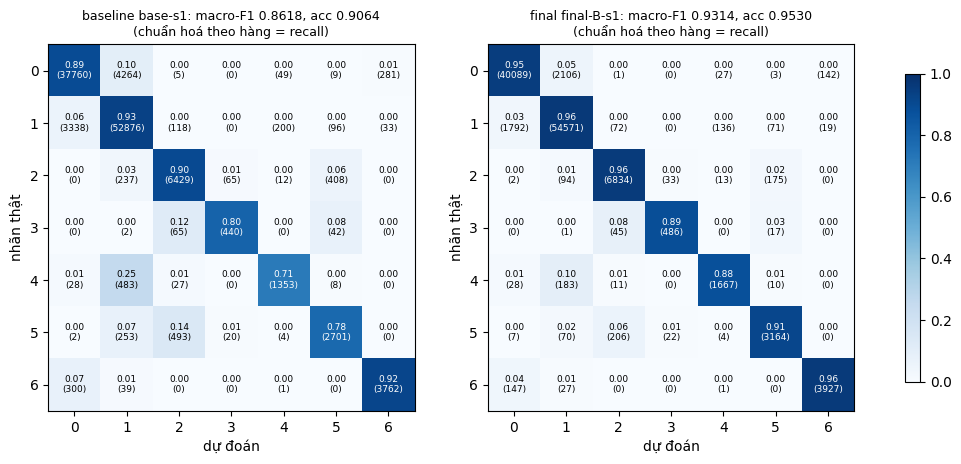

lớp khó nhất (final): 4 (Aspen), F1 = 0.8898; hay bị nhầm thành lớp 1 (183 / 1899 mẫu)
cặp nhầm lẫn nhiều nhất về số lượng: thật 0 -> đoán 1: 2106 mẫu


In [18]:
# Phân tích lỗi theo lớp trên eval
names = ["Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine", "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"]
rows = []
for tag_, res in (("baseline", EVAL_BASE), ("final", EVAL_FINAL)):
    for pc in res["per_class"]:
        rows.append(dict(model=tag_, cls=pc["cls"], name=names[pc["cls"]], support=pc["support"],
                         precision=pc["precision"], recall=pc["recall"], f1=pc["f1"]))
df_cls = pd.DataFrame(rows).pivot(index=["cls", "name", "support"], columns="model", values=["precision", "recall", "f1"])
with pd.option_context("display.float_format", "{:.4f}".format, "display.width", 200):
    display(df_cls)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (tag_, res) in zip(axes, (("baseline base-s1", EVAL_BASE), (f"final {chosen['cfg']['exp_id']}", EVAL_FINAL))):
    cm = np.array(res["confusion_matrix"])
    cmn = cm / cm.sum(1, keepdims=True)
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for i in range(7):
        for j in range(7):
            ax.text(j, i, f"{cmn[i, j]:.2f}\n({cm[i, j]})", ha="center", va="center", fontsize=6.5,
                    color="white" if cmn[i, j] > 0.5 else "black")
    ax.set_xticks(range(7)); ax.set_yticks(range(7))
    ax.set_xlabel("dự đoán"); ax.set_ylabel("nhãn thật")
    ax.set_title(f"{tag_}: macro-F1 {res['macro_f1']:.4f}, acc {res['accuracy']:.4f}\n(chuẩn hoá theo hàng = recall)", fontsize=9)
fig.colorbar(im, ax=axes, shrink=0.8)
fig.savefig(f"{OUT_DIR}/figures/compare_eval_confusion.png", dpi=110, bbox_inches="tight"); plt.show()

cm = np.array(EVAL_FINAL["confusion_matrix"])
off = cm.copy(); np.fill_diagonal(off, 0)
f1c = np.array([pc["f1"] for pc in EVAL_FINAL["per_class"]])
hard = int(f1c.argmin())
print(f"lớp khó nhất (final): {hard} ({names[hard]}), F1 = {f1c[hard]:.4f}; hay bị nhầm thành lớp {int(off[hard].argmax())} "
      f"({off[hard].max()} / {cm[hard].sum()} mẫu)")
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"cặp nhầm lẫn nhiều nhất về số lượng: thật {i} -> đoán {j}: {off[i, j]} mẫu")

**Phân tích lỗi (eval, cấu hình cuối `final-B-s1`):**
- Mọi lớp đều cải thiện so với baseline; lớp hiếm cải thiện nhiều nhất: lớp 4 (Aspen) F1 0,769 → 0,890, lớp 5 (Douglas-fir) 0,802 → 0,915, lớp 3 (Cottonwood/Willow) 0,819 → 0,892.
- **Lớp khó nhất: lớp 4 (Aspen), F1 = 0,8898** (recall 0,878), sát sau là lớp 3 (F1 0,8917). Aspen bị nhầm nhiều nhất thành **lớp 1 (Lodgepole Pine): 183/1 899 mẫu (9,6%)**. Lý do (đã đo): Aspen chỉ chiếm 1,6% dữ liệu trong khi Lodgepole Pine chiếm 48,8%, nên CE không trọng số kéo ranh giới về phía lớp đa số. Lý do (phỏng đoán, chưa kiểm chứng bằng phân tích đặc trưng): hai loài này phân bố ở dải độ cao và loại đất chồng lấn.
- Lớp 3 (0,5% dữ liệu, 549 mẫu) nhầm sang lớp 2 Ponderosa Pine (45) và lớp 5 Douglas-fir (17) — phỏng đoán: ba loài này cùng ở vùng thấp nên đặc trưng địa hình giống nhau. Lớp 5 cũng nhầm sang lớp 2 (206 mẫu).
- Về số lượng tuyệt đối, cặp nhầm lớn nhất là **0 ↔ 1** (Spruce/Fir → Lodgepole 2 106, ngược lại 1 792): hai lớp lớn nhất, phỏng đoán là chồng lấn về độ cao.
- Cách cải thiện sẽ thử: trọng số lớp trong CE (tỉ lệ nghịch tần suất) hoặc lấy mẫu cân bằng để tăng recall lớp 3/4/5; chọn checkpoint theo val macro-F1 thay vì val loss.

In [19]:
# Bảng experiments.xlsx: mỗi exp_id một dòng; eval chỉ cho baseline (base-s1) và cấu hình cuối
GROUP_ORDER = ["baseline", "loss", "optimizer", "hparam", "dropout", "clipping", "amp", "init", "final"]
results = load_results(f"{OUT_DIR}/results")
results.sort(key=lambda r: (GROUP_ORDER.index(r["cfg"]["group"]), r["cfg"]["exp_id"]))
eval_map = {"base-s1": EVAL_BASE, chosen["cfg"]["exp_id"]: EVAL_FINAL}
rows = [to_row(r, eval_map.get(r["cfg"]["exp_id"]),
               notes=("trùng cấu hình base-s1 (kiểm tra tái lập)" if r["cfg"]["exp_id"] == f"opt-sgdm-lr{BASE_LR:g}" else "")
                     + ("cấu hình cuối, file nộp" if r["cfg"]["exp_id"] == chosen["cfg"]["exp_id"] else ""))
        for r in results]

def best_of(group):
    g = [r for r in results if r["cfg"]["group"] == group and r["summary"]["val_macro_f1"] is not None]
    b = max(g, key=lambda r: r["summary"]["val_macro_f1"])
    d = b["summary"]["val_macro_f1"] - BASE_F1
    return f"tốt nhất {b['cfg']['exp_id']} (val F1 {b['summary']['val_macro_f1']:.4f}, Δ {d:+.4f} so với TB baseline, {'vượt' if abs(d) > NOISE else 'trong'} 2σ={NOISE:.4f})"

SUMMARY_NOTES = {g: best_of(g) for g in GROUP_ORDER if any(r["cfg"]["group"] == g for r in results)}
SUMMARY_NOTES["baseline"] = f"3 seed: val F1 {BASE_F1:.4f} ± {BASE_SD:.4f}; lr={BASE_LR:g} chọn bằng val; eval F1 {EVAL_BASE['macro_f1']:.4f}"
SUMMARY_NOTES["final"] = (f"{chosen['cfg']['exp_id']}: val F1 {ff1.mean():.4f} ± {ff1.std(ddof=1):.4f} (3 seed); "
                          f"eval F1 {EVAL_FINAL['macro_f1']:.4f} (baseline {EVAL_BASE['macro_f1']:.4f})")
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seed_ids=["base-s1", "base-s2", "base-s3"], summary_notes=SUMMARY_NOTES)
figs = {p.stem for p in Path(f"{OUT_DIR}/figures").glob("*.png") if not p.stem.startswith("compare_")}
ids = {r["exp_id"] for r in rows}
print(len(rows), "dòng trong bảng;", len(figs), "ảnh <exp_id>.png;", "khớp" if figs == ids else f"LỆCH: {figs ^ ids}")
assert figs == ids
for k, v in SUMMARY_NOTES.items():
    print(f"{k:9s} {v}")

45 dòng trong bảng; 45 ảnh <exp_id>.png; khớp
baseline  3 seed: val F1 0.8562 ± 0.0019; lr=0.1 chọn bằng val; eval F1 0.8618
loss      tốt nhất loss-mse-lrx3 (val F1 0.7887, Δ -0.0675 so với TB baseline, vượt 2σ=0.0037)
optimizer tốt nhất opt-adamw-lr0.003 (val F1 0.8757, Δ +0.0195 so với TB baseline, vượt 2σ=0.0037)
hparam    tốt nhất hp-ep40 (val F1 0.8743, Δ +0.0181 so với TB baseline, vượt 2σ=0.0037)
dropout   tốt nhất drop-0.1 (val F1 0.8368, Δ -0.0194 so với TB baseline, vượt 2σ=0.0037)
clipping  tốt nhất clip-0.58 (val F1 0.8591, Δ +0.0028 so với TB baseline, trong 2σ=0.0037)
amp       tốt nhất amp-wide-fp16 (val F1 0.8821, Δ +0.0259 so với TB baseline, vượt 2σ=0.0037)
init      tốt nhất init-xavier (val F1 0.8585, Δ +0.0023 so với TB baseline, trong 2σ=0.0037)
final     final-B-s1: val F1 0.9252 ± 0.0033 (3 seed); eval F1 0.9314 (baseline 0.8618)


In [20]:
# Đóng gói: chép code hoàn chỉnh vào submission_<MSSV>/code/ (notebook có output được chép sau khi lưu)
import shutil
dst = Path(OUT_DIR) / "code"; dst.mkdir(exist_ok=True)
for f in ("data.py", "model.py", "optimizer.py", "train.py", "plots.py", "results_table.py", "runner.py"):
    shutil.copy(Path(CODE_DIR) / f, dst / f)
print(sorted(p.name for p in dst.iterdir()))
print("Thư mục nộp:", OUT_DIR)
print(sorted(p.name for p in Path(OUT_DIR).iterdir()))

['data.py', 'lab.ipynb', 'model.py', 'optimizer.py', 'plots.py', 'results_table.py', 'runner.py', 'train.py']
Thư mục nộp: /content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602457
['baseline_eval', 'code', 'eval_result.json', 'experiments.xlsx', 'figures', 'predictions_eval.csv', 'results']
